# CP260-2026 — Metric-Semantic Reconstruction Pipeline

**Approach:** Manual 2D bbox annotations + multi-view triangulation + depth-prior OBB fitting.
No GroundingDINO / SAM required — avoids all the C++ extension failures.

**Run order:** Cell 1 → restart runtime → Cells 2–6

In [1]:
# ── Cell 1: Install dependencies ─────────────────────────────────────────────
# Run this cell ONCE, then restart the runtime before continuing.
import subprocess, sys

def pip(cmd):
    r = subprocess.run([sys.executable, "-m", "pip"] + cmd.split(),
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(f"[WARNING] {cmd[:50]}... rc={r.returncode}")
        print(r.stderr[-400:] if r.stderr else "")
    return r.returncode

print("Installing open3d...")
pip("install open3d==0.19.0 -q")
print("Installing tqdm, scipy, Pillow...")
pip("install tqdm scipy Pillow -q")

print("\n✅ All packages installed.")
print("👉 Runtime → Restart runtime → run from Cell 2")

Installing open3d...
Installing tqdm, scipy, Pillow...

✅ All packages installed.
👉 Runtime → Restart runtime → run from Cell 2


In [1]:
# ── Cell 2: Write source package to disk ─────────────────────────────────────
# No additional file upload needed — everything is embedded here.

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/project")
SRC = PROJECT_ROOT / "src"
SRC.mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "output" / "detections").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "output" / "depth_maps").mkdir(parents=True, exist_ok=True)
(PROJECT_ROOT / "output" / "visualizations").mkdir(parents=True, exist_ok=True)

# ── __init__.py ───────────────────────────────────────────────────────────────
(SRC / "__init__.py").write_text(
    "# Metric-Semantic Reconstruction Pipeline — CP260-2026 Final Project\n"
)

# ── intrinsic.json ────────────────────────────────────────────────────────────
import json
(PROJECT_ROOT / "intrinsic.json").write_text(json.dumps({
    "camera_matrix": [
        [1477.00974684544,    0.0,               1298.2501500778505],
        [0.0,                1480.4424455584467,  686.8201623541711],
        [0.0,                0.0,                1.0              ]
    ],
    "image_width": 2560,
    "image_height": 1440,
    "note": "Undistorted pinhole intrinsics",
    "distortion_coefficients": [0.0, 0.0, 0.0, 0.0, 0.0]
}, indent=2))

# ── config.py ─────────────────────────────────────────────────────────────────
(SRC / "config.py").write_text('''
"""
Configuration for the Metric-Semantic Reconstruction Pipeline.
CP260-2026 — Colab-adapted paths.
"""
import os
import numpy as np

# ─── Paths (Colab) ───────────────────────────────────────────────────────────
PROJECT_ROOT   = "/content/project"
DATA_DIR       = "/content/project/Data"
OUTPUT_DIR     = "/content/project/output"
INTRINSIC_PATH = "/content/project/intrinsic.json"
POSES_PATH     = "/content/project/Data/poses.json"
SAMPLE_ANSWERS_PATH = "/content/project/sample_answers.json"

# ─── Camera Intrinsics ───────────────────────────────────────────────────────
IMAGE_WIDTH  = 2560
IMAGE_HEIGHT = 1440
FX = 1477.00974684544
FY = 1480.4424455584467
CX = 1298.2501500778505
CY = 686.8201623541711

CAMERA_MATRIX = np.array([
    [FX, 0.0, CX],
    [0.0, FY, CY],
    [0.0, 0.0, 1.0]
], dtype=np.float64)

# ─── Frame indices ───────────────────────────────────────────────────────────
FRAME_INDICES = [319, 333, 353, 359, 365, 371, 390, 400,
                 426, 449, 461, 468, 471, 496, 515, 531]

# ─── Processing parameters ──────────────────────────────────────────────────
SCALE_FACTOR          = 0.5
SIFT_N_FEATURES       = 8000
MATCH_RATIO_THRESH    = 0.75
TRIANGULATION_REPROJ_THRESH = 4.0

# ─── Reconstruction parameters ──────────────────────────────────────────────
VOXEL_SIZE     = 0.002
SOR_NB_NEIGHBORS = 30
SOR_STD_RATIO  = 1.5

# ─── Ensure output directories exist ────────────────────────────────────────
for subdir in ["", "detections", "depth_maps", "visualizations"]:
    os.makedirs(os.path.join(OUTPUT_DIR, subdir), exist_ok=True)
''')

# ── data_loader.py ────────────────────────────────────────────────────────────
(SRC / "data_loader.py").write_text('''
"""
Data loading utilities.
Loads images, camera poses (4x4 extrinsics), and intrinsic parameters.
"""
import os
import json
import cv2
import numpy as np
from . import config


def load_intrinsics(path=None):
    """Load camera intrinsic matrix from JSON file."""
    if path is None:
        path = config.INTRINSIC_PATH
    with open(path, \'r\') as f:
        data = json.load(f)
    K = np.array(data[\'camera_matrix\'], dtype=np.float64)
    return K


def load_poses(path=None):
    """
    Load all camera poses from poses.json.
    Returns dict: {frame_index(int): 4x4 numpy array (camera-to-world)}.
    """
    if path is None:
        path = config.POSES_PATH
    with open(path, \'r\') as f:
        raw = json.load(f)
    poses = {}
    for key, mat in raw.items():
        poses[int(key)] = np.array(mat, dtype=np.float64)
    return poses


def load_images(frame_indices=None, scale=1.0):
    """
    Load images for the specified frame indices.
    Returns dict: {frame_index: BGR image as numpy array}
    """
    if frame_indices is None:
        frame_indices = config.FRAME_INDICES
    images = {}
    for idx in frame_indices:
        fname = f"frame_{idx:06d}.png"
        fpath = os.path.join(config.DATA_DIR, fname)
        if not os.path.exists(fpath):
            print(f"  [WARN] Image not found: {fpath}")
            continue
        img = cv2.imread(fpath)
        if img is None:
            print(f"  [WARN] Failed to read: {fpath}")
            continue
        if scale != 1.0:
            img = cv2.resize(img, None, fx=scale, fy=scale,
                             interpolation=cv2.INTER_AREA)
        images[idx] = img
    return images


def get_scaled_intrinsics(K, scale):
    """Scale the camera intrinsic matrix by a factor."""
    K_scaled = K.copy()
    K_scaled[0, 0] *= scale
    K_scaled[1, 1] *= scale
    K_scaled[0, 2] *= scale
    K_scaled[1, 2] *= scale
    return K_scaled


def get_projection_matrix(K, pose_c2w):
    """
    Build a 3x4 projection matrix P = K @ [R|t] (world-to-image).
    pose_c2w: 4x4 camera-to-world transformation
    """
    pose_w2c = np.linalg.inv(pose_c2w)
    R = pose_w2c[:3, :3]
    t = pose_w2c[:3, 3:]
    Rt = np.hstack([R, t])
    return K @ Rt


def load_sample_answers(path=None):
    """Load sample_answers.json, tolerating placeholder values."""
    import re
    if path is None:
        path = config.SAMPLE_ANSWERS_PATH
    if not os.path.exists(path):
        return []
    with open(path, \'r\') as f:
        raw = f.read()
    try:
        return json.loads(raw)
    except json.JSONDecodeError:
        pass
    cleaned = raw
    for ph in [\'X\', \'Y\', \'Z\', \'W\', \'H\', \'L\', \'rx\', \'ry\', \'rz\']:
        cleaned = re.sub(r\'(?<!["\\w])\' + ph + r\'(?!["\\w])\', \'0.0\', cleaned)
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        print(f"  [WARN] Could not parse sample_answers.json: {e}")
        return []


def load_dataset():
    """Convenience: load images, poses, and intrinsics at once."""
    print("[1/3] Loading intrinsics...")
    K = load_intrinsics()
    print("[2/3] Loading poses...")
    all_poses = load_poses()
    poses = {idx: all_poses[idx] for idx in config.FRAME_INDICES if idx in all_poses}
    print("[3/3] Loading images...")
    images = load_images()
    print(f"  Loaded {len(images)} images, {len(poses)} poses")
    return images, poses, K
''')

# ── semantic.py ───────────────────────────────────────────────────────────────
# NOTE: The bboxes below are approximate — refine them if results are off.
# Frames 471 and 496 show the back panel most clearly.
# Format: [x1, y1, x2, y2] in the original 2560×1440 resolution.
(SRC / "semantic.py").write_text('''
"""
Semantic annotation module — manual 2D bounding boxes.
Pixel coords [x1, y1, x2, y2] in original 2560x1440 resolution.

HOW TO REFINE ON EXAM DAY:
  1. Run Cell 4 (preview) to see the annotated frames.
  2. Adjust bbox coordinates below until they tightly wrap each port.
  3. Re-run Cell 5.
"""
import cv2
import numpy as np
from . import config

# ─── Manual 2D Annotations ───────────────────────────────────────────────────
# Frames 471 and 496 show the back panel most clearly.
ENTITY_ANNOTATIONS = {
    "power_socket": {
        471: [1140, 1020, 1280, 1100],
        496: [1670, 1060, 1820, 1155],
    },
    "ethernet_socket": {
        471: [1160, 305, 1280, 405],
        496: [1735, 305, 1845, 405],
    },
    "vga_socket": {
        471: [1101, 357, 1285, 423],
        496: [1671, 364, 1855, 430],
    },
}


def get_annotations(entity_name=None):
    if entity_name is None:
        return ENTITY_ANNOTATIONS
    return ENTITY_ANNOTATIONS.get(entity_name, {})


def get_annotated_frames(entity_name):
    return list(ENTITY_ANNOTATIONS.get(entity_name, {}).keys())


def get_entity_names():
    return list(ENTITY_ANNOTATIONS.keys())


def get_roi_center(bbox):
    x1, y1, x2, y2 = bbox
    return ((x1 + x2) / 2.0, (y1 + y2) / 2.0)


def get_roi_points(bbox, n_samples=100):
    x1, y1, x2, y2 = bbox
    nx = max(int(np.sqrt(n_samples * (x2 - x1) / max(y2 - y1, 1))), 3)
    ny = max(int(np.sqrt(n_samples * (y2 - y1) / max(x2 - x1, 1))), 3)
    xs = np.linspace(x1, x2, nx)
    ys = np.linspace(y1, y2, ny)
    xx, yy = np.meshgrid(xs, ys)
    return np.column_stack([xx.ravel(), yy.ravel()])


def visualize_annotations(images, output_dir=None):
    import os
    if output_dir is None:
        output_dir = os.path.join(config.OUTPUT_DIR, "detections")
    colors = {
        "power_socket":    (0, 0, 255),
        "ethernet_socket": (255, 0, 0),
        "vga_socket":      (0, 255, 0),
    }
    for idx, img in images.items():
        vis = img.copy()
        has_ann = False
        for entity_name, ann_dict in ENTITY_ANNOTATIONS.items():
            if idx in ann_dict:
                bbox  = ann_dict[idx]
                color = colors.get(entity_name, (0, 255, 255))
                x1, y1, x2, y2 = bbox
                cv2.rectangle(vis, (x1, y1), (x2, y2), color, 3)
                cv2.putText(vis, entity_name, (x1, y1 - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
                has_ann = True
        if has_ann:
            out_path = os.path.join(output_dir, f"annotated_{idx:06d}.png")
            cv2.imwrite(out_path, vis)
            print(f"  Saved: {out_path}")
''')

# ── pose_estimation.py ────────────────────────────────────────────────────────
(SRC / "pose_estimation.py").write_text('''
"""
3D Pose Estimation via multi-view triangulation and OBB fitting.
"""
import cv2
import numpy as np
from itertools import combinations
from . import config
from .data_loader import get_projection_matrix
from .semantic import (
    get_annotations, get_entity_names, get_roi_center,
    get_roi_points, get_annotated_frames
)

# Physical depth priors (meters) — connector protrusion from back panel
DEPTH_PRIORS = {
    "vga_socket":       0.006,
    "ethernet_socket":  0.006,
    "power_socket":     0.006,
}


def triangulate_point_multiview(point_2d_per_view, K, poses):
    """Triangulate a single 3D point from 2D observations (DLT)."""
    frame_indices = list(point_2d_per_view.keys())
    if len(frame_indices) < 2:
        return None
    A = []
    for idx in frame_indices:
        P = get_projection_matrix(K, poses[idx])
        u, v = point_2d_per_view[idx]
        A.append(u * P[2, :] - P[0, :])
        A.append(v * P[2, :] - P[1, :])
    A = np.array(A)
    _, _, Vt = np.linalg.svd(A)
    X = Vt[-1]
    X = X[:3] / X[3]
    for idx in frame_indices:
        pose_w2c = np.linalg.inv(poses[idx])
        pt_cam = pose_w2c[:3, :3] @ X + pose_w2c[:3, 3]
        if pt_cam[2] <= 0:
            return None
    return X


def triangulate_roi_multiview(entity_name, annotations, K, poses,
                               n_grid_points=400):
    """Triangulate 3D points for an entity ROI from all annotated view pairs."""
    entity_ann  = annotations.get(entity_name, {})
    frame_indices = sorted(entity_ann.keys())
    if len(frame_indices) < 2:
        print(f"  [WARN] Need >=2 views for {entity_name}, got {len(frame_indices)}")
        return np.zeros((0, 3))

    all_points = []
    n_side = int(np.sqrt(n_grid_points))
    ts = np.linspace(0.05, 0.95, n_side)

    for idx1, idx2 in combinations(frame_indices, 2):
        if idx1 not in poses or idx2 not in poses:
            continue
        bbox1 = entity_ann[idx1]
        bbox2 = entity_ann[idx2]
        P1 = get_projection_matrix(K, poses[idx1])
        P2 = get_projection_matrix(K, poses[idx2])
        w2c1 = np.linalg.inv(poses[idx1])
        w2c2 = np.linalg.inv(poses[idx2])

        for ty in ts:
            for tx in ts:
                u1 = bbox1[0] + tx * (bbox1[2] - bbox1[0])
                v1 = bbox1[1] + ty * (bbox1[3] - bbox1[1])
                u2 = bbox2[0] + tx * (bbox2[2] - bbox2[0])
                v2 = bbox2[1] + ty * (bbox2[3] - bbox2[1])
                pts4d = cv2.triangulatePoints(
                    P1, P2,
                    np.array([[u1, v1]], dtype=np.float64).T,
                    np.array([[u2, v2]], dtype=np.float64).T
                )
                pt3d = (pts4d[:3] / pts4d[3:]).flatten()
                z1 = (w2c1[:3, :3] @ pt3d + w2c1[:3, 3])[2]
                z2 = (w2c2[:3, :3] @ pt3d + w2c2[:3, 3])[2]
                if z1 > 0 and z2 > 0:
                    p1h = P1 @ np.append(pt3d, 1)
                    p2h = P2 @ np.append(pt3d, 1)
                    e1  = np.linalg.norm(p1h[:2]/p1h[2] - [u1, v1])
                    e2  = np.linalg.norm(p2h[:2]/p2h[2] - [u2, v2])
                    if e1 < 50 and e2 < 50:
                        all_points.append(pt3d)

    if len(all_points) == 0:
        print(f"  [WARN] No 3D points for {entity_name}")
        return np.zeros((0, 3))

    pts = _remove_outliers_mad(np.array(all_points))
    print(f"  {entity_name}: triangulated {len(pts)} 3D points")
    return pts


def _remove_outliers_mad(points, threshold=3.0):
    """Remove outliers using Median Absolute Deviation."""
    if len(points) < 5:
        return points
    median  = np.median(points, axis=0)
    diffs   = np.linalg.norm(points - median, axis=1)
    med_diff = np.median(diffs)
    mad     = 1.4826 * med_diff
    if mad < 1e-10:
        return points
    return points[diffs < threshold * mad]


def estimate_panel_directions(entity_name, annotations, K, poses):
    """Estimate panel up/across/normal directions via corner triangulation."""
    entity_ann    = annotations.get(entity_name, {})
    frame_indices = sorted(entity_ann.keys())
    if len(frame_indices) < 2:
        return None, None, None
    idx1, idx2 = frame_indices[0], frame_indices[1]
    bbox1 = entity_ann[idx1]
    bbox2 = entity_ann[idx2]
    P1 = get_projection_matrix(K, poses[idx1])
    P2 = get_projection_matrix(K, poses[idx2])

    def tri(u1, v1, u2, v2):
        pts4d = cv2.triangulatePoints(
            P1, P2,
            np.array([[u1, v1]], dtype=np.float64).T,
            np.array([[u2, v2]], dtype=np.float64).T
        )
        return (pts4d[:3] / pts4d[3:]).flatten()

    tl = tri(bbox1[0], bbox1[1], bbox2[0], bbox2[1])
    tr = tri(bbox1[2], bbox1[1], bbox2[2], bbox2[1])
    bl = tri(bbox1[0], bbox1[3], bbox2[0], bbox2[3])
    br = tri(bbox1[2], bbox1[3], bbox2[2], bbox2[3])

    across_dir = ((tr - tl) + (br - bl)) / 2.0
    across_dir /= np.linalg.norm(across_dir) + 1e-12
    down_dir   = ((bl - tl) + (br - tr)) / 2.0
    down_dir   /= np.linalg.norm(down_dir) + 1e-12
    normal_dir  = np.cross(across_dir, down_dir)
    normal_dir /= np.linalg.norm(normal_dir) + 1e-12

    return down_dir, across_dir, normal_dir


def fit_obb_with_depth(points_3d, entity_name, annotations, K, poses):
    """Fit OBB using triangulated surface + physical depth prior."""
    if len(points_3d) < 3:
        print("  [WARN] Too few points for OBB fitting")
        return None

    center   = np.mean(points_3d, axis=0)
    centered = points_3d - center

    down_dir, across_dir, normal_dir = estimate_panel_directions(
        entity_name, annotations, K, poses
    )

    row0 = normal_dir.copy()
    if row0[1] < 0:
        row0 = -row0
    row2 = across_dir.copy()
    if row2[0] < 0:
        row2 = -row2
    row1  = np.cross(row2, row0)
    row1 /= np.linalg.norm(row1) + 1e-12
    row0  = np.cross(row1, row2)
    row0 /= np.linalg.norm(row0) + 1e-12
    R = np.array([row0, row1, row2])

    _, eigenvectors = np.linalg.eigh(np.cov(centered.T))
    projected_pca   = centered @ eigenvectors
    pca_spreads     = (projected_pca.max(axis=0) - projected_pca.min(axis=0)) / 2.0

    depth_prior = DEPTH_PRIORS.get(entity_name, 0.006)
    extent    = np.zeros(3)
    extent[0] = pca_spreads[2]
    extent[1] = pca_spreads[1]
    extent[2] = depth_prior
    if extent[1] < depth_prior / 2.0:
        extent[1] = depth_prior

    projected = centered @ R.T
    center_offset = R.T @ ((projected.min(axis=0) + projected.max(axis=0)) / 2.0)
    center = center + center_offset

    return {
        "center":   center.tolist(),
        "extent":   extent.tolist(),
        "rotation": R.tolist()
    }


def estimate_all_poses(annotations, K, poses, n_grid_points=400):
    """Estimate OBBs for all annotated entities."""
    print("\n=== OBB Pose Estimation ===")
    results = []
    for entity_name in get_entity_names():
        print(f"\n  Processing: {entity_name}")
        pts = triangulate_roi_multiview(
            entity_name, annotations, K, poses, n_grid_points
        )
        if len(pts) < 3:
            print(f"  [SKIP] Not enough points for {entity_name}")
            continue
        obb = fit_obb_with_depth(pts, entity_name, annotations, K, poses)
        if obb is None:
            continue
        results.append({"entity": entity_name, "obb": obb})
        print(f"    Center: {[round(v,4) for v in obb[\'center\']]  }")
        print(f"    Extent: {[round(v,4) for v in obb[\'extent\']]  }")
    return results


def validate_with_projection(results, images, K, poses):
    """Project OBBs onto frames and save visualizations."""
    import os
    from .utils import project_obb_to_image, draw_obb_on_image

    colors = {
        "power_socket":    (0, 0, 255),
        "ethernet_socket": (255, 0, 0),
        "vga_socket":      (0, 255, 0),
    }
    for idx in [471, 496, 515]:
        if idx not in images or idx not in poses:
            continue
        vis = images[idx].copy()
        for res in results:
            color = colors.get(res[\'entity\'], (0, 255, 255))
            corners_2d = project_obb_to_image(res[\'obb\'], K, poses[idx])
            vis = draw_obb_on_image(vis, corners_2d, label=res[\'entity\'], color=color)
        out = os.path.join(config.OUTPUT_DIR, "detections",
                           f"obb_projection_{idx:06d}.png")
        cv2.imwrite(out, vis)
        print(f"  Saved OBB projection: {out}")
''')

# ── utils.py ──────────────────────────────────────────────────────────────────
(SRC / "utils.py").write_text('''
"""
Visualization and I/O utilities.
"""
import json
import cv2
import numpy as np


def project_obb_to_image(obb, K, pose_c2w):
    """Project OBB 8 corners onto image plane. Returns (8,2) array."""
    center  = np.array(obb[\'center\'])
    extent  = np.array(obb[\'extent\'])
    R_obb   = np.array(obb[\'rotation\'])
    signs   = np.array([
        [-1,-1,-1],[-1,-1,1],[-1,1,-1],[-1,1,1],
        [1,-1,-1], [1,-1,1], [1,1,-1], [1,1,1]
    ], dtype=np.float64)
    corners_world = (R_obb @ (signs * extent).T).T + center
    pose_w2c = np.linalg.inv(pose_c2w)
    corners_cam = (pose_w2c[:3,:3] @ corners_world.T).T + pose_w2c[:3,3]
    corners_2d = np.full((8, 2), np.nan)
    for i in range(8):
        if corners_cam[i,2] > 0:
            pt = K @ corners_cam[i]
            corners_2d[i] = pt[:2] / pt[2]
    return corners_2d


def draw_obb_on_image(image, corners_2d, label="", color=(0,255,0), thickness=2):
    """Draw OBB wireframe (12 edges) on a copy of image."""
    if corners_2d is None:
        return image
    vis  = image.copy()
    pts  = corners_2d.astype(int)
    edges = [(0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7)]
    for i, j in edges:
        if not (np.isnan(corners_2d[i]).any() or np.isnan(corners_2d[j]).any()):
            cv2.line(vis, tuple(pts[i]), tuple(pts[j]), color, thickness)
    if label:
        valid = pts[~np.isnan(corners_2d).any(axis=1)]
        if len(valid) > 0:
            tl = valid.min(axis=0)
            cv2.putText(vis, label, tuple(tl - [0,10]),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
    return vis


def save_answers_json(entities, output_path):
    """Save OBB answers in submission format."""
    output = []
    for ent in entities:
        output.append({
            "entity": ent["entity"],
            "obb": {
                "center":   [float(v) for v in ent["obb"]["center"]],
                "extent":   [float(v) for v in ent["obb"]["extent"]],
                "rotation": [[float(v) for v in row] for row in ent["obb"]["rotation"]]
            }
        })
    with open(output_path, \'w\') as f:
        json.dump(output, f, indent=2)
    print(f"  Saved answers to {output_path}")


def validate_against_sample(answers, sample_answers):
    """Compare VGA socket prediction against ground truth."""
    sample_vga = next((s[\'obb\'] for s in sample_answers if s[\'entity\'] == \'vga_socket\'), None)
    our_vga    = next((a[\'obb\'] for a in answers    if a[\'entity\'] == \'vga_socket\'), None)
    if sample_vga is None:
        print("  [INFO] No VGA socket in sample answers")
        return
    if our_vga is None:
        print("  [INFO] No VGA socket predicted")
        return
    c_s = np.array(sample_vga[\'center\'])
    c_o = np.array(our_vga[\'center\'])
    dist = np.linalg.norm(c_s - c_o)
    print(f"\n  === VGA Socket Validation ===")
    print(f"  Center distance: {dist:.4f} m  ({dist*1000:.1f} mm)")
    print(f"    GT:   {np.round(c_s, 4).tolist()}")
    print(f"    Pred: {np.round(c_o, 4).tolist()}")
    e_s = np.sort(np.array(sample_vga[\'extent\'  ]))[::-1]
    e_o = np.sort(np.array(our_vga[\'extent\'    ]))[::-1]
    print(f"  Extents (sorted): GT={np.round(e_s,4).tolist()}  Pred={np.round(e_o,4).tolist()}")
    R_s = np.array(sample_vga[\'rotation\'])
    R_o = np.array(our_vga[\'rotation\'])
    try:
        trace = np.clip(np.trace(R_o @ R_s.T), -1.0, 3.0)
        angle = np.degrees(np.arccos(np.clip((trace - 1) / 2, -1, 1)))
        print(f"  Rotation error: {angle:.1f}°")
    except Exception as e:
        print(f"  Rotation error: {e}")
    if dist < 0.05:
        print("  ✅ GOOD (< 5 cm)")
    elif dist < 0.10:
        print("  ⚠️  Acceptable (< 10 cm)")
    else:
        print("  ❌ Large error — check bbox coordinates in semantic.py")
''')

print("✅ Source package written to /content/project/src/")
print(f"Files created: {[f.name for f in SRC.glob('*.py')]}")

✅ Source package written to /content/project/src/
Files created: ['__init__.py', 'config.py', 'utils.py', 'pose_estimation.py', 'data_loader.py', 'semantic.py']


In [2]:
# ── Cell 3: Upload Data.zip ───────────────────────────────────────────────────
import zipfile, os, json
from pathlib import Path
from google.colab import files

print("📂 Upload your Data.zip (contains frame_*.png images + poses.json)")
uploaded = files.upload()
zip_path = list(uploaded.keys())[0]

extract_root = Path("/content/project")
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(str(extract_root))

# Auto-detect Data/ folder
data_dir = None
for candidate in [
    extract_root / "Data",
    extract_root / "data",
]:
    if candidate.exists():
        data_dir = candidate
        break

if data_dir is None:
    # Find directory with .png files
    for root, dirs, fnames in os.walk(str(extract_root)):
        if any(f.endswith(".png") for f in fnames):
            data_dir = Path(root)
            break

if data_dir is None:
    raise RuntimeError("❌ Could not find image directory — check your zip structure")

# Ensure config.DATA_DIR matches actual location
imgs = sorted([f for f in os.listdir(data_dir) if f.endswith(".png")])
poses_path = data_dir / "poses.json"
if not poses_path.exists():
    poses_path = extract_root / "poses.json"

print(f"\n✅ Data directory : {data_dir}")
print(f"✅ Found {len(imgs)} images : {imgs[0]} → {imgs[-1]}")
print(f"✅ Poses file     : {poses_path}")

# Patch config if paths differ from defaults
import sys
sys.path.insert(0, "/content/project")
import importlib
import src.config as cfg

cfg.DATA_DIR   = str(data_dir)
cfg.POSES_PATH = str(poses_path)

print("\n✅ config paths patched")

📂 Upload your Data.zip (contains frame_*.png images + poses.json)


Saving Data.zip to Data.zip

✅ Data directory : /content/project/Data
✅ Found 16 images : frame_000319.png → frame_000531.png
✅ Poses file     : /content/project/Data/poses.json

✅ config paths patched


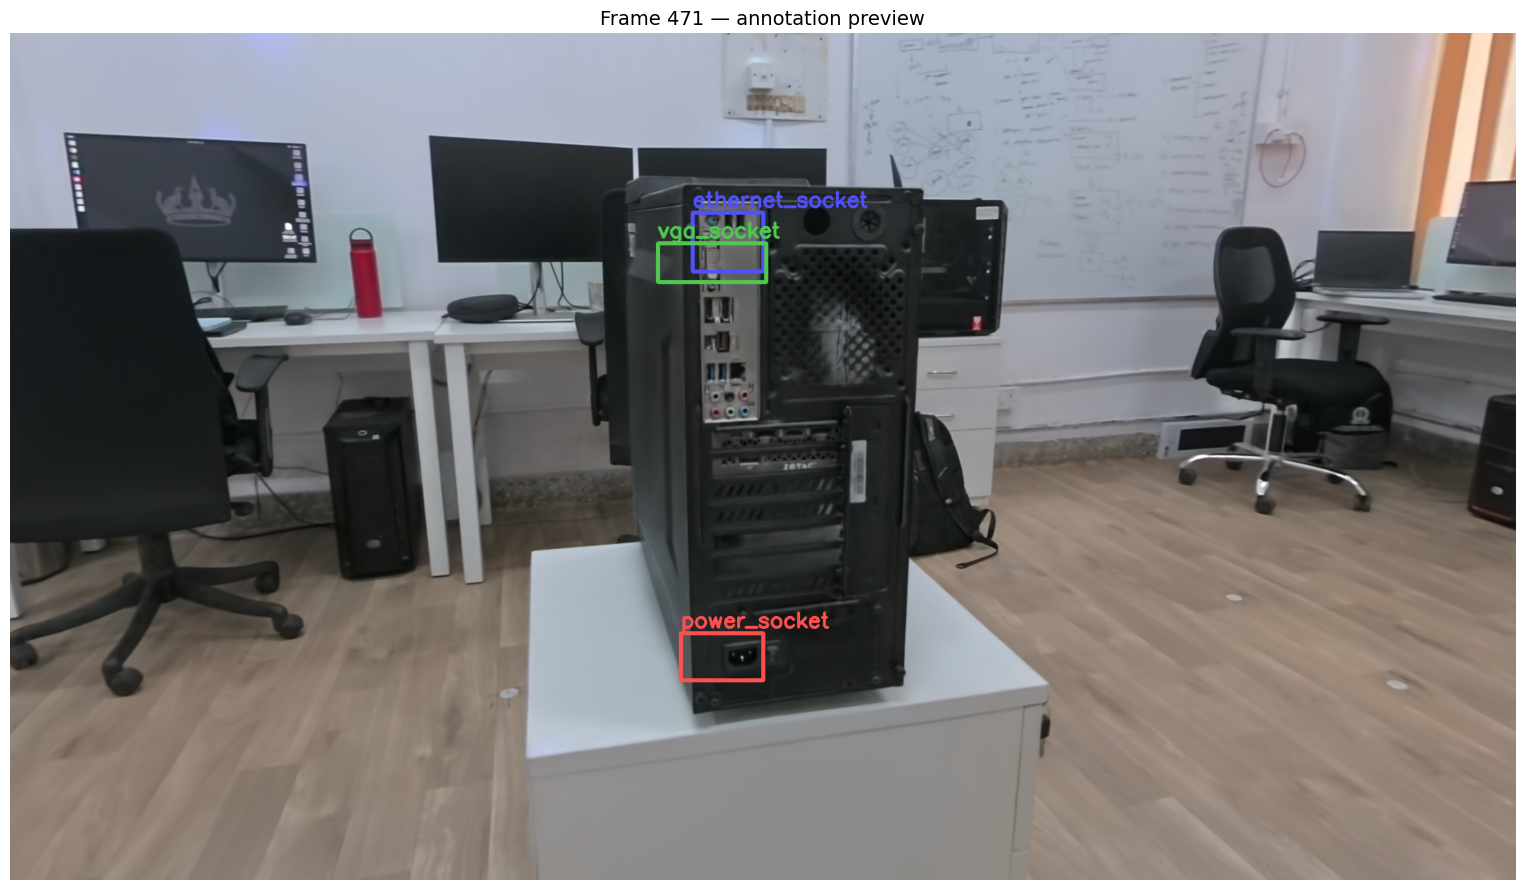

▲ Check that all 3 boxes are tightly around their ports in frame 471
  If not: edit ENTITY_ANNOTATIONS in Cell 2, re-run Cells 2→5.


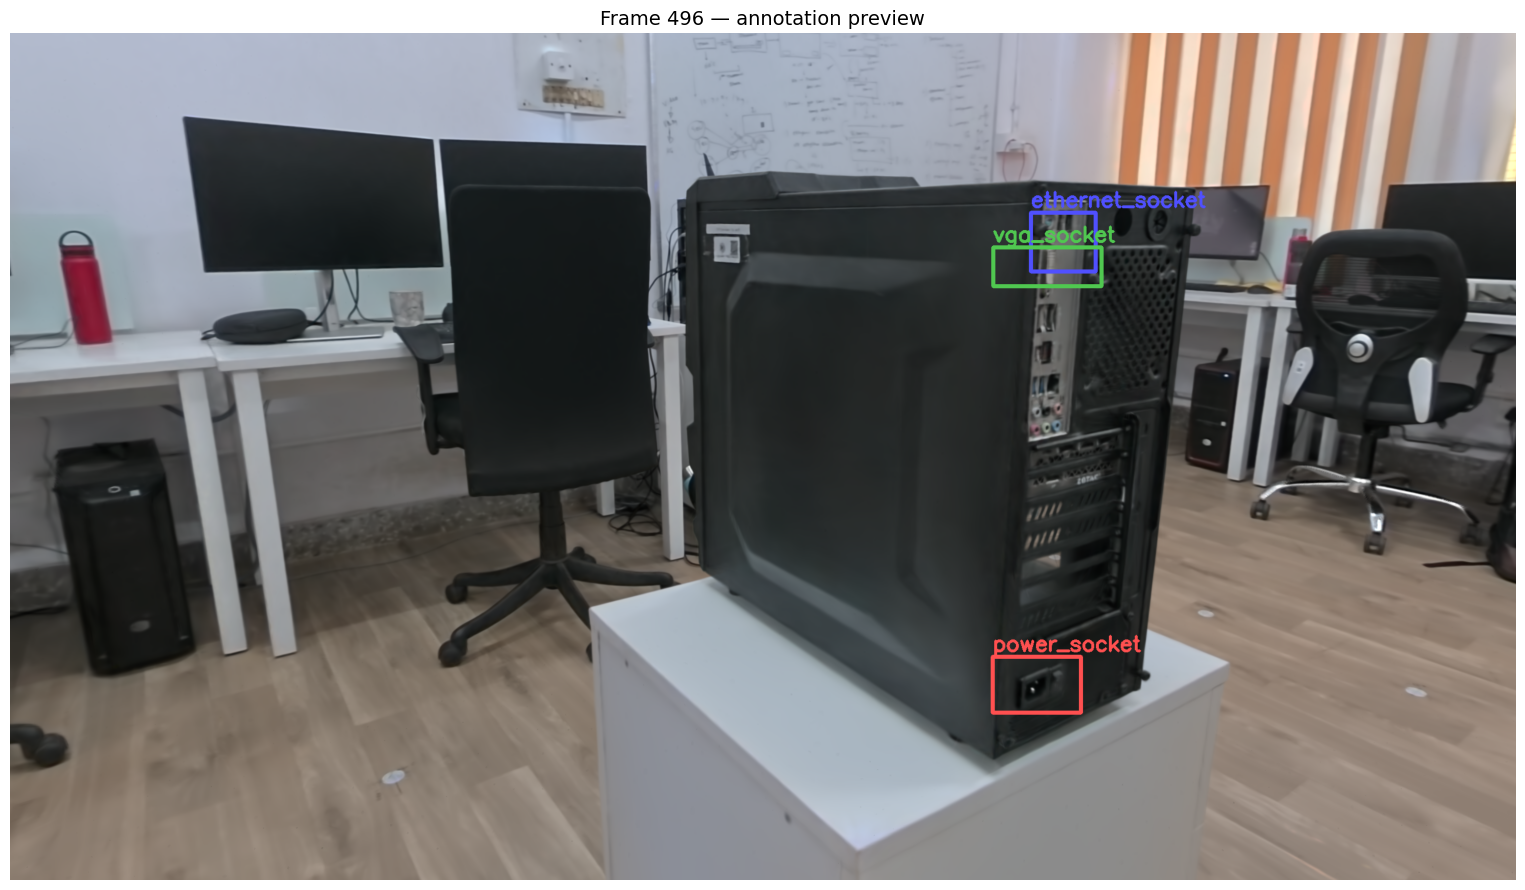

▲ Check that all 3 boxes are tightly around their ports in frame 496
  If not: edit ENTITY_ANNOTATIONS in Cell 2, re-run Cells 2→5.


In [3]:
# ── Cell 4: Preview annotations on frames 471 & 496 ──────────────────────────
# This lets you verify that the bboxes are correct before running the pipeline.
# If a box is in the wrong place, edit the coordinates in Cell 2 (semantic.py)
# and re-run Cells 2, 3, 4, 5.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import src.config as cfg
from src.semantic import ENTITY_ANNOTATIONS

colors = {
    "power_socket":    (255, 80, 80),
    "ethernet_socket": (80, 80, 255),
    "vga_socket":      (80, 200, 80),
}

for frame_idx in [471, 496]:
    img_path = Path(cfg.DATA_DIR) / f"frame_{frame_idx:06d}.png"
    if not img_path.exists():
        print(f"[SKIP] {img_path} not found")
        continue
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    vis = img_rgb.copy()
    for entity, ann_dict in ENTITY_ANNOTATIONS.items():
        if frame_idx in ann_dict:
            x1, y1, x2, y2 = ann_dict[frame_idx]
            c = colors.get(entity, (200, 200, 0))
            cv2.rectangle(vis, (x1, y1), (x2, y2), c, 5)
            cv2.putText(vis, entity, (x1, max(y1-10, 20)),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, c, 3)
    plt.figure(figsize=(18, 9))
    plt.imshow(vis)
    plt.title(f"Frame {frame_idx} — annotation preview", fontsize=14)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    print(f"▲ Check that all 3 boxes are tightly around their ports in frame {frame_idx}")
    print(f"  If not: edit ENTITY_ANNOTATIONS in Cell 2, re-run Cells 2→5.")

In [8]:
# ── PASTE THIS AS A NEW CELL — run it, then re-run Cell 5 ──────────────────
# Fixes SyntaxError in pose_estimation.py and utils.py caused by
# quote-escaping bugs in the original Cell 2 write_text() calls.

import base64
from pathlib import Path

SRC = Path("/content/project/src")

_pose_b64 = "IiIiCnBvc2VfZXN0aW1hdGlvbi5weSDigJQgZml4ZWQgdmVyc2lvbiAobm8gbmVzdGVkIGYtc3RyaW5nIHF1b3RlIGlzc3VlcykKIiIiCmltcG9ydCBjdjIKaW1wb3J0IG51bXB5IGFzIG5wCmZyb20gaXRlcnRvb2xzIGltcG9ydCBjb21iaW5hdGlvbnMKZnJvbSAuIGltcG9ydCBjb25maWcKZnJvbSAuZGF0YV9sb2FkZXIgaW1wb3J0IGdldF9wcm9qZWN0aW9uX21hdHJpeApmcm9tIC5zZW1hbnRpYyBpbXBvcnQgKAogICAgZ2V0X2Fubm90YXRpb25zLCBnZXRfZW50aXR5X25hbWVzLCBnZXRfcm9pX2NlbnRlciwKICAgIGdldF9yb2lfcG9pbnRzLCBnZXRfYW5ub3RhdGVkX2ZyYW1lcwopCgpERVBUSF9QUklPUlMgPSB7CiAgICAidmdhX3NvY2tldCI6ICAgICAgIDAuMDA2LAogICAgImV0aGVybmV0X3NvY2tldCI6ICAwLjAwNiwKICAgICJwb3dlcl9zb2NrZXQiOiAgICAgMC4wMDYsCn0KCgpkZWYgdHJpYW5ndWxhdGVfcG9pbnRfbXVsdGl2aWV3KHBvaW50XzJkX3Blcl92aWV3LCBLLCBwb3Nlcyk6CiAgICBmcmFtZV9pbmRpY2VzID0gbGlzdChwb2ludF8yZF9wZXJfdmlldy5rZXlzKCkpCiAgICBpZiBsZW4oZnJhbWVfaW5kaWNlcykgPCAyOgogICAgICAgIHJldHVybiBOb25lCiAgICBBID0gW10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBQID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeF0pCiAgICAgICAgdSwgdiA9IHBvaW50XzJkX3Blcl92aWV3W2lkeF0KICAgICAgICBBLmFwcGVuZCh1ICogUFsyLCA6XSAtIFBbMCwgOl0pCiAgICAgICAgQS5hcHBlbmQodiAqIFBbMiwgOl0gLSBQWzEsIDpdKQogICAgQSA9IG5wLmFycmF5KEEpCiAgICBfLCBfLCBWdCA9IG5wLmxpbmFsZy5zdmQoQSkKICAgIFggPSBWdFstMV0KICAgIFggPSBYWzozXSAvIFhbM10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBwb3NlX3cyYyA9IG5wLmxpbmFsZy5pbnYocG9zZXNbaWR4XSkKICAgICAgICBwdF9jYW0gPSBwb3NlX3cyY1s6MywgOjNdIEAgWCArIHBvc2VfdzJjWzozLCAzXQogICAgICAgIGlmIHB0X2NhbVsyXSA8PSAwOgogICAgICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuIFgKCgpkZWYgdHJpYW5ndWxhdGVfcm9pX211bHRpdmlldyhlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLAogICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgbl9ncmlkX3BvaW50cz00MDApOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICBwcmludCgiICBbV0FSTl0gTmVlZCA+PTIgdmlld3MgZm9yICVzLCBnb3QgJWQiICUgKGVudGl0eV9uYW1lLCBsZW4oZnJhbWVfaW5kaWNlcykpKQogICAgICAgIHJldHVybiBucC56ZXJvcygoMCwgMykpCgogICAgYWxsX3BvaW50cyA9IFtdCiAgICBuX3NpZGUgPSBpbnQobnAuc3FydChuX2dyaWRfcG9pbnRzKSkKICAgIHRzID0gbnAubGluc3BhY2UoMC4wNSwgMC45NSwgbl9zaWRlKQoKICAgIGZvciBpZHgxLCBpZHgyIGluIGNvbWJpbmF0aW9ucyhmcmFtZV9pbmRpY2VzLCAyKToKICAgICAgICBpZiBpZHgxIG5vdCBpbiBwb3NlcyBvciBpZHgyIG5vdCBpbiBwb3NlczoKICAgICAgICAgICAgY29udGludWUKICAgICAgICBiYm94MSA9IGVudGl0eV9hbm5baWR4MV0KICAgICAgICBiYm94MiA9IGVudGl0eV9hbm5baWR4Ml0KICAgICAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgICAgICBQMiA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgyXSkKICAgICAgICB3MmMxID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgxXSkKICAgICAgICB3MmMyID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgyXSkKCiAgICAgICAgZm9yIHR5IGluIHRzOgogICAgICAgICAgICBmb3IgdHggaW4gdHM6CiAgICAgICAgICAgICAgICB1MSA9IGJib3gxWzBdICsgdHggKiAoYmJveDFbMl0gLSBiYm94MVswXSkKICAgICAgICAgICAgICAgIHYxID0gYmJveDFbMV0gKyB0eSAqIChiYm94MVszXSAtIGJib3gxWzFdKQogICAgICAgICAgICAgICAgdTIgPSBiYm94MlswXSArIHR4ICogKGJib3gyWzJdIC0gYmJveDJbMF0pCiAgICAgICAgICAgICAgICB2MiA9IGJib3gyWzFdICsgdHkgKiAoYmJveDJbM10gLSBiYm94MlsxXSkKICAgICAgICAgICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICAgICAgICAgIFAxLCBQMiwKICAgICAgICAgICAgICAgICAgICBucC5hcnJheShbW3UxLCB2MV1dLCBkdHlwZT1ucC5mbG9hdDY0KS5ULAogICAgICAgICAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIHB0M2QgPSAocHRzNGRbOjNdIC8gcHRzNGRbMzpdKS5mbGF0dGVuKCkKICAgICAgICAgICAgICAgIHoxID0gKHcyYzFbOjMsIDozXSBAIHB0M2QgKyB3MmMxWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIHoyID0gKHcyYzJbOjMsIDozXSBAIHB0M2QgKyB3MmMyWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIGlmIHoxID4gMCBhbmQgejIgPiAwOgogICAgICAgICAgICAgICAgICAgIHAxaCA9IFAxIEAgbnAuYXBwZW5kKHB0M2QsIDEpCiAgICAgICAgICAgICAgICAgICAgcDJoID0gUDIgQCBucC5hcHBlbmQocHQzZCwgMSkKICAgICAgICAgICAgICAgICAgICBlMSAgPSBucC5saW5hbGcubm9ybShwMWhbOjJdL3AxaFsyXSAtIFt1MSwgdjFdKQogICAgICAgICAgICAgICAgICAgIGUyICA9IG5wLmxpbmFsZy5ub3JtKHAyaFs6Ml0vcDJoWzJdIC0gW3UyLCB2Ml0pCiAgICAgICAgICAgICAgICAgICAgaWYgZTEgPCA1MCBhbmQgZTIgPCA1MDoKICAgICAgICAgICAgICAgICAgICAgICAgYWxsX3BvaW50cy5hcHBlbmQocHQzZCkKCiAgICBpZiBsZW4oYWxsX3BvaW50cykgPT0gMDoKICAgICAgICBwcmludCgiICBbV0FSTl0gTm8gM0QgcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICByZXR1cm4gbnAuemVyb3MoKDAsIDMpKQoKICAgIHB0cyA9IF9yZW1vdmVfb3V0bGllcnNfbWFkKG5wLmFycmF5KGFsbF9wb2ludHMpKQogICAgcHJpbnQoIiAgJXM6IHRyaWFuZ3VsYXRlZCAlZCAzRCBwb2ludHMiICUgKGVudGl0eV9uYW1lLCBsZW4ocHRzKSkpCiAgICByZXR1cm4gcHRzCgoKZGVmIF9yZW1vdmVfb3V0bGllcnNfbWFkKHBvaW50cywgdGhyZXNob2xkPTMuMCk6CiAgICBpZiBsZW4ocG9pbnRzKSA8IDU6CiAgICAgICAgcmV0dXJuIHBvaW50cwogICAgbWVkaWFuICAgPSBucC5tZWRpYW4ocG9pbnRzLCBheGlzPTApCiAgICBkaWZmcyAgICA9IG5wLmxpbmFsZy5ub3JtKHBvaW50cyAtIG1lZGlhbiwgYXhpcz0xKQogICAgbWVkX2RpZmYgPSBucC5tZWRpYW4oZGlmZnMpCiAgICBtYWQgICAgICA9IDEuNDgyNiAqIG1lZF9kaWZmCiAgICBpZiBtYWQgPCAxZS0xMDoKICAgICAgICByZXR1cm4gcG9pbnRzCiAgICByZXR1cm4gcG9pbnRzW2RpZmZzIDwgdGhyZXNob2xkICogbWFkXQoKCmRlZiBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMpOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICByZXR1cm4gTm9uZSwgTm9uZSwgTm9uZQogICAgaWR4MSwgaWR4MiA9IGZyYW1lX2luZGljZXNbMF0sIGZyYW1lX2luZGljZXNbMV0KICAgIGJib3gxID0gZW50aXR5X2FubltpZHgxXQogICAgYmJveDIgPSBlbnRpdHlfYW5uW2lkeDJdCiAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgIFAyID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeDJdKQoKICAgIGRlZiB0cmkodTEsIHYxLCB1MiwgdjIpOgogICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICBQMSwgUDIsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTEsIHYxXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICApCiAgICAgICAgcmV0dXJuIChwdHM0ZFs6M10gLyBwdHM0ZFszOl0pLmZsYXR0ZW4oKQoKICAgIHRsID0gdHJpKGJib3gxWzBdLCBiYm94MVsxXSwgYmJveDJbMF0sIGJib3gyWzFdKQogICAgdHIgPSB0cmkoYmJveDFbMl0sIGJib3gxWzFdLCBiYm94MlsyXSwgYmJveDJbMV0pCiAgICBibCA9IHRyaShiYm94MVswXSwgYmJveDFbM10sIGJib3gyWzBdLCBiYm94MlszXSkKICAgIGJyID0gdHJpKGJib3gxWzJdLCBiYm94MVszXSwgYmJveDJbMl0sIGJib3gyWzNdKQoKICAgIGFjcm9zc19kaXIgID0gKCh0ciAtIHRsKSArIChiciAtIGJsKSkgLyAyLjAKICAgIGFjcm9zc19kaXIgLz0gbnAubGluYWxnLm5vcm0oYWNyb3NzX2RpcikgKyAxZS0xMgogICAgZG93bl9kaXIgICAgPSAoKGJsIC0gdGwpICsgKGJyIC0gdHIpKSAvIDIuMAogICAgZG93bl9kaXIgICAvPSBucC5saW5hbGcubm9ybShkb3duX2RpcikgKyAxZS0xMgogICAgbm9ybWFsX2RpciAgPSBucC5jcm9zcyhhY3Jvc3NfZGlyLCBkb3duX2RpcikKICAgIG5vcm1hbF9kaXIgLz0gbnAubGluYWxnLm5vcm0obm9ybWFsX2RpcikgKyAxZS0xMgoKICAgIHJldHVybiBkb3duX2RpciwgYWNyb3NzX2Rpciwgbm9ybWFsX2RpcgoKCmRlZiBmaXRfb2JiX3dpdGhfZGVwdGgocG9pbnRzXzNkLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKToKICAgIGlmIGxlbihwb2ludHNfM2QpIDwgMzoKICAgICAgICBwcmludCgiICBbV0FSTl0gVG9vIGZldyBwb2ludHMgZm9yIE9CQiBmaXR0aW5nIikKICAgICAgICByZXR1cm4gTm9uZQoKICAgIGNlbnRlciAgID0gbnAubWVhbihwb2ludHNfM2QsIGF4aXM9MCkKICAgIGNlbnRlcmVkID0gcG9pbnRzXzNkIC0gY2VudGVyCgogICAgZG93bl9kaXIsIGFjcm9zc19kaXIsIG5vcm1hbF9kaXIgPSBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKAogICAgICAgIGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMKICAgICkKICAgIGlmIG5vcm1hbF9kaXIgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZQoKICAgIHJvdzAgPSBub3JtYWxfZGlyLmNvcHkoKQogICAgaWYgcm93MFsxXSA8IDA6CiAgICAgICAgcm93MCA9IC1yb3cwCiAgICByb3cyID0gYWNyb3NzX2Rpci5jb3B5KCkKICAgIGlmIHJvdzJbMF0gPCAwOgogICAgICAgIHJvdzIgPSAtcm93MgogICAgcm93MSAgPSBucC5jcm9zcyhyb3cyLCByb3cwKQogICAgcm93MSAvPSBucC5saW5hbGcubm9ybShyb3cxKSArIDFlLTEyCiAgICByb3cwICA9IG5wLmNyb3NzKHJvdzEsIHJvdzIpCiAgICByb3cwIC89IG5wLmxpbmFsZy5ub3JtKHJvdzApICsgMWUtMTIKICAgIFIgPSBucC5hcnJheShbcm93MCwgcm93MSwgcm93Ml0pCgogICAgXywgZWlnZW52ZWN0b3JzID0gbnAubGluYWxnLmVpZ2gobnAuY292KGNlbnRlcmVkLlQpKQogICAgcHJvamVjdGVkX3BjYSAgID0gY2VudGVyZWQgQCBlaWdlbnZlY3RvcnMKICAgIHBjYV9zcHJlYWRzICAgICA9IChwcm9qZWN0ZWRfcGNhLm1heChheGlzPTApIC0gcHJvamVjdGVkX3BjYS5taW4oYXhpcz0wKSkgLyAyLjAKCiAgICBkZXB0aF9wcmlvciA9IERFUFRIX1BSSU9SUy5nZXQoZW50aXR5X25hbWUsIDAuMDA2KQogICAgZXh0ZW50ICAgICAgPSBucC56ZXJvcygzKQogICAgZXh0ZW50WzBdICAgPSBwY2Ffc3ByZWFkc1syXQogICAgZXh0ZW50WzFdICAgPSBwY2Ffc3ByZWFkc1sxXQogICAgZXh0ZW50WzJdICAgPSBkZXB0aF9wcmlvcgogICAgaWYgZXh0ZW50WzFdIDwgZGVwdGhfcHJpb3IgLyAyLjA6CiAgICAgICAgZXh0ZW50WzFdID0gZGVwdGhfcHJpb3IKCiAgICBwcm9qZWN0ZWQgICAgID0gY2VudGVyZWQgQCBSLlQKICAgIGNlbnRlcl9vZmZzZXQgPSBSLlQgQCAoKHByb2plY3RlZC5taW4oYXhpcz0wKSArIHByb2plY3RlZC5tYXgoYXhpcz0wKSkgLyAyLjApCiAgICBjZW50ZXIgICAgICAgID0gY2VudGVyICsgY2VudGVyX29mZnNldAoKICAgIHJldHVybiB7CiAgICAgICAgImNlbnRlciI6ICAgY2VudGVyLnRvbGlzdCgpLAogICAgICAgICJleHRlbnQiOiAgIGV4dGVudC50b2xpc3QoKSwKICAgICAgICAicm90YXRpb24iOiBSLnRvbGlzdCgpCiAgICB9CgoKZGVmIGVzdGltYXRlX2FsbF9wb3Nlcyhhbm5vdGF0aW9ucywgSywgcG9zZXMsIG5fZ3JpZF9wb2ludHM9NDAwKToKICAgIHByaW50KCJcbj09PSBPQkIgUG9zZSBFc3RpbWF0aW9uID09PSIpCiAgICByZXN1bHRzID0gW10KICAgIGZvciBlbnRpdHlfbmFtZSBpbiBnZXRfZW50aXR5X25hbWVzKCk6CiAgICAgICAgcHJpbnQoIlxuICBQcm9jZXNzaW5nOiAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICBwdHMgPSB0cmlhbmd1bGF0ZV9yb2lfbXVsdGl2aWV3KAogICAgICAgICAgICBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLCBuX2dyaWRfcG9pbnRzCiAgICAgICAgKQogICAgICAgIGlmIGxlbihwdHMpIDwgMzoKICAgICAgICAgICAgcHJpbnQoIiAgW1NLSVBdIE5vdCBlbm91Z2ggcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICAgICAgY29udGludWUKICAgICAgICBvYmIgPSBmaXRfb2JiX3dpdGhfZGVwdGgocHRzLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKQogICAgICAgIGlmIG9iYiBpcyBOb25lOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHJlc3VsdHMuYXBwZW5kKHsiZW50aXR5IjogZW50aXR5X25hbWUsICJvYmIiOiBvYmJ9KQogICAgICAgIGMgPSBbcm91bmQodiwgNCkgZm9yIHYgaW4gb2JiWyJjZW50ZXIiXV0KICAgICAgICBlID0gW3JvdW5kKHYsIDQpIGZvciB2IGluIG9iYlsiZXh0ZW50Il1dCiAgICAgICAgcHJpbnQoIiAgICBDZW50ZXI6ICVzIiAlIGMpCiAgICAgICAgcHJpbnQoIiAgICBFeHRlbnQ6ICVzIiAlIGUpCiAgICByZXR1cm4gcmVzdWx0cwoKCmRlZiB2YWxpZGF0ZV93aXRoX3Byb2plY3Rpb24ocmVzdWx0cywgaW1hZ2VzLCBLLCBwb3Nlcyk6CiAgICBpbXBvcnQgb3MKICAgIGltcG9ydCBjdjIKICAgIGZyb20gLnV0aWxzIGltcG9ydCBwcm9qZWN0X29iYl90b19pbWFnZSwgZHJhd19vYmJfb25faW1hZ2UKCiAgICBjb2xvcnMgPSB7CiAgICAgICAgInBvd2VyX3NvY2tldCI6ICAgICgwLCAwLCAyNTUpLAogICAgICAgICJldGhlcm5ldF9zb2NrZXQiOiAoMjU1LCAwLCAwKSwKICAgICAgICAidmdhX3NvY2tldCI6ICAgICAgKDAsIDI1NSwgMCksCiAgICB9CiAgICBmb3IgaWR4IGluIFs0NzEsIDQ5NiwgNTE1XToKICAgICAgICBpZiBpZHggbm90IGluIGltYWdlcyBvciBpZHggbm90IGluIHBvc2VzOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHZpcyA9IGltYWdlc1tpZHhdLmNvcHkoKQogICAgICAgIGZvciByZXMgaW4gcmVzdWx0czoKICAgICAgICAgICAgY29sb3IgICAgICA9IGNvbG9ycy5nZXQocmVzWyJlbnRpdHkiXSwgKDAsIDI1NSwgMjU1KSkKICAgICAgICAgICAgY29ybmVyc18yZCA9IHByb2plY3Rfb2JiX3RvX2ltYWdlKHJlc1sib2JiIl0sIEssIHBvc2VzW2lkeF0pCiAgICAgICAgICAgIHZpcyAgICAgICAgPSBkcmF3X29iYl9vbl9pbWFnZSh2aXMsIGNvcm5lcnNfMmQsCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBsYWJlbD1yZXNbImVudGl0eSJdLCBjb2xvcj1jb2xvcikKICAgICAgICBvdXQgPSBvcy5wYXRoLmpvaW4oY29uZmlnLk9VVFBVVF9ESVIsICJkZXRlY3Rpb25zIiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgIm9iYl9wcm9qZWN0aW9uXyUwNmQucG5nIiAlIGlkeCkKICAgICAgICBjdjIuaW13cml0ZShvdXQsIHZpcykKICAgICAgICBwcmludCgiICBTYXZlZCBPQkIgcHJvamVjdGlvbjogJXMiICUgb3V0KQo="
_utils_b64 = "IiIiCnV0aWxzLnB5IOKAlCB2aXN1YWxpemF0aW9uIGFuZCBJL08gdXRpbGl0aWVzIChmaXhlZCkKIiIiCmltcG9ydCBqc29uCmltcG9ydCBjdjIKaW1wb3J0IG51bXB5IGFzIG5wCgoKZGVmIHByb2plY3Rfb2JiX3RvX2ltYWdlKG9iYiwgSywgcG9zZV9jMncpOgogICAgY2VudGVyICA9IG5wLmFycmF5KG9iYlsiY2VudGVyIl0pCiAgICBleHRlbnQgID0gbnAuYXJyYXkob2JiWyJleHRlbnQiXSkKICAgIFJfb2JiICAgPSBucC5hcnJheShvYmJbInJvdGF0aW9uIl0pCiAgICBzaWducyAgID0gbnAuYXJyYXkoWwogICAgICAgIFstMSwtMSwtMV0sWy0xLC0xLDFdLFstMSwxLC0xXSxbLTEsMSwxXSwKICAgICAgICBbIDEsLTEsLTFdLFsgMSwtMSwxXSxbIDEsMSwtMV0sWyAxLDEsMV0KICAgIF0sIGR0eXBlPW5wLmZsb2F0NjQpCiAgICBjb3JuZXJzX3dvcmxkID0gKFJfb2JiIEAgKHNpZ25zICogZXh0ZW50KS5UKS5UICsgY2VudGVyCiAgICBwb3NlX3cyYyAgICAgID0gbnAubGluYWxnLmludihwb3NlX2MydykKICAgIGNvcm5lcnNfY2FtICAgPSAocG9zZV93MmNbOjMsOjNdIEAgY29ybmVyc193b3JsZC5UKS5UICsgcG9zZV93MmNbOjMsM10KICAgIGNvcm5lcnNfMmQgICAgPSBucC5mdWxsKCg4LCAyKSwgbnAubmFuKQogICAgZm9yIGkgaW4gcmFuZ2UoOCk6CiAgICAgICAgaWYgY29ybmVyc19jYW1baSwyXSA+IDA6CiAgICAgICAgICAgIHB0ID0gSyBAIGNvcm5lcnNfY2FtW2ldCiAgICAgICAgICAgIGNvcm5lcnNfMmRbaV0gPSBwdFs6Ml0gLyBwdFsyXQogICAgcmV0dXJuIGNvcm5lcnNfMmQKCgpkZWYgZHJhd19vYmJfb25faW1hZ2UoaW1hZ2UsIGNvcm5lcnNfMmQsIGxhYmVsPSIiLCBjb2xvcj0oMCwyNTUsMCksIHRoaWNrbmVzcz0yKToKICAgIGlmIGNvcm5lcnNfMmQgaXMgTm9uZToKICAgICAgICByZXR1cm4gaW1hZ2UKICAgIHZpcyAgID0gaW1hZ2UuY29weSgpCiAgICBwdHMgICA9IGNvcm5lcnNfMmQuYXN0eXBlKGludCkKICAgIGVkZ2VzID0gWygwLDEpLCgwLDIpLCgwLDQpLCgxLDMpLCgxLDUpLCgyLDMpLAogICAgICAgICAgICAgKDIsNiksKDMsNyksKDQsNSksKDQsNiksKDUsNyksKDYsNyldCiAgICBmb3IgaSwgaiBpbiBlZGdlczoKICAgICAgICBpZiBub3QgKG5wLmlzbmFuKGNvcm5lcnNfMmRbaV0pLmFueSgpIG9yIG5wLmlzbmFuKGNvcm5lcnNfMmRbal0pLmFueSgpKToKICAgICAgICAgICAgY3YyLmxpbmUodmlzLCB0dXBsZShwdHNbaV0pLCB0dXBsZShwdHNbal0pLCBjb2xvciwgdGhpY2tuZXNzKQogICAgaWYgbGFiZWw6CiAgICAgICAgdmFsaWQgPSBwdHNbfm5wLmlzbmFuKGNvcm5lcnNfMmQpLmFueShheGlzPTEpXQogICAgICAgIGlmIGxlbih2YWxpZCkgPiAwOgogICAgICAgICAgICB0bCA9IHZhbGlkLm1pbihheGlzPTApCiAgICAgICAgICAgIGN2Mi5wdXRUZXh0KHZpcywgbGFiZWwsIHR1cGxlKHRsIC0gWzAsIDEwXSksCiAgICAgICAgICAgICAgICAgICAgICAgIGN2Mi5GT05UX0hFUlNIRVlfU0lNUExFWCwgMC44LCBjb2xvciwgMikKICAgIHJldHVybiB2aXMKCgpkZWYgZHJhd19iYm94X29uX2ltYWdlKGltYWdlLCBiYm94LCBsYWJlbD0iIiwgY29sb3I9KDAsMjU1LDApLCB0aGlja25lc3M9Mik6CiAgICB2aXMgPSBpbWFnZS5jb3B5KCkKICAgIHgxLCB5MSwgeDIsIHkyID0gW2ludCh2KSBmb3IgdiBpbiBiYm94XQogICAgY3YyLnJlY3RhbmdsZSh2aXMsICh4MSwgeTEpLCAoeDIsIHkyKSwgY29sb3IsIHRoaWNrbmVzcykKICAgIGlmIGxhYmVsOgogICAgICAgIGN2Mi5wdXRUZXh0KHZpcywgbGFiZWwsICh4MSwgeTEgLSAxMCksCiAgICAgICAgICAgICAgICAgICAgY3YyLkZPTlRfSEVSU0hFWV9TSU1QTEVYLCAwLjcsIGNvbG9yLCAyKQogICAgcmV0dXJuIHZpcwoKCmRlZiBzYXZlX2Fuc3dlcnNfanNvbihlbnRpdGllcywgb3V0cHV0X3BhdGgpOgogICAgb3V0cHV0ID0gW10KICAgIGZvciBlbnQgaW4gZW50aXRpZXM6CiAgICAgICAgb3V0cHV0LmFwcGVuZCh7CiAgICAgICAgICAgICJlbnRpdHkiOiBlbnRbImVudGl0eSJdLAogICAgICAgICAgICAib2JiIjogewogICAgICAgICAgICAgICAgImNlbnRlciI6ICAgW2Zsb2F0KHYpIGZvciB2IGluIGVudFsib2JiIl1bImNlbnRlciJdXSwKICAgICAgICAgICAgICAgICJleHRlbnQiOiAgIFtmbG9hdCh2KSBmb3IgdiBpbiBlbnRbIm9iYiJdWyJleHRlbnQiXV0sCiAgICAgICAgICAgICAgICAicm90YXRpb24iOiBbW2Zsb2F0KHYpIGZvciB2IGluIHJvd10KICAgICAgICAgICAgICAgICAgICAgICAgICAgICBmb3Igcm93IGluIGVudFsib2JiIl1bInJvdGF0aW9uIl1dCiAgICAgICAgICAgIH0KICAgICAgICB9KQogICAgd2l0aCBvcGVuKG91dHB1dF9wYXRoLCAidyIpIGFzIGY6CiAgICAgICAganNvbi5kdW1wKG91dHB1dCwgZiwgaW5kZW50PTIpCiAgICBwcmludCgiICBTYXZlZCBhbnN3ZXJzIHRvICVzIiAlIG91dHB1dF9wYXRoKQoKCmRlZiB2YWxpZGF0ZV9hZ2FpbnN0X3NhbXBsZShhbnN3ZXJzLCBzYW1wbGVfYW5zd2Vycyk6CiAgICBzYW1wbGVfdmdhID0gbmV4dCgoc1sib2JiIl0gZm9yIHMgaW4gc2FtcGxlX2Fuc3dlcnMKICAgICAgICAgICAgICAgICAgICAgICBpZiBzWyJlbnRpdHkiXSA9PSAidmdhX3NvY2tldCIpLCBOb25lKQogICAgb3VyX3ZnYSAgICA9IG5leHQoKGFbIm9iYiJdIGZvciBhIGluIGFuc3dlcnMKICAgICAgICAgICAgICAgICAgICAgICBpZiBhWyJlbnRpdHkiXSA9PSAidmdhX3NvY2tldCIpLCBOb25lKQogICAgaWYgc2FtcGxlX3ZnYSBpcyBOb25lOgogICAgICAgIHByaW50KCIgIFtJTkZPXSBObyBWR0Egc29ja2V0IGluIHNhbXBsZSBhbnN3ZXJzIikKICAgICAgICByZXR1cm4KICAgIGlmIG91cl92Z2EgaXMgTm9uZToKICAgICAgICBwcmludCgiICBbSU5GT10gTm8gVkdBIHNvY2tldCBwcmVkaWN0ZWQiKQogICAgICAgIHJldHVybgoKICAgIGNfcyAgPSBucC5hcnJheShzYW1wbGVfdmdhWyJjZW50ZXIiXSkKICAgIGNfbyAgPSBucC5hcnJheShvdXJfdmdhWyJjZW50ZXIiXSkKICAgIGRpc3QgPSBucC5saW5hbGcubm9ybShjX3MgLSBjX28pCiAgICBwcmludCgiXG4gID09PSBWR0EgU29ja2V0IFZhbGlkYXRpb24gPT09IikKICAgIHByaW50KCIgIENlbnRlciBkaXN0YW5jZTogJS40ZiBtICAoJS4xZiBtbSkiICUgKGRpc3QsIGRpc3QgKiAxMDAwKSkKICAgIHByaW50KCIgICAgR1Q6ICAgJXMiICUgbnAucm91bmQoY19zLCA0KS50b2xpc3QoKSkKICAgIHByaW50KCIgICAgUHJlZDogJXMiICUgbnAucm91bmQoY19vLCA0KS50b2xpc3QoKSkKCiAgICBlX3MgPSBucC5zb3J0KG5wLmFycmF5KHNhbXBsZV92Z2FbImV4dGVudCJdKSlbOjotMV0KICAgIGVfbyA9IG5wLnNvcnQobnAuYXJyYXkob3VyX3ZnYVsiZXh0ZW50Il0pKVs6Oi0xXQogICAgcHJpbnQoIiAgRXh0ZW50cyBzb3J0ZWQg4oCUIEdUOiAlcyAgUHJlZDogJXMiICUgKAogICAgICAgICAgbnAucm91bmQoZV9zLDQpLnRvbGlzdCgpLCBucC5yb3VuZChlX28sNCkudG9saXN0KCkpKQoKICAgIFJfcyA9IG5wLmFycmF5KHNhbXBsZV92Z2FbInJvdGF0aW9uIl0pCiAgICBSX28gPSBucC5hcnJheShvdXJfdmdhWyJyb3RhdGlvbiJdKQogICAgdHJ5OgogICAgICAgIHRyYWNlID0gbnAuY2xpcChucC50cmFjZShSX28gQCBSX3MuVCksIC0xLjAsIDMuMCkKICAgICAgICBhbmdsZSA9IG5wLmRlZ3JlZXMobnAuYXJjY29zKG5wLmNsaXAoKHRyYWNlIC0gMSkgLyAyLCAtMSwgMSkpKQogICAgICAgIHByaW50KCIgIFJvdGF0aW9uIGVycm9yOiAlLjFmIGRlZyIgJSBhbmdsZSkKICAgIGV4Y2VwdCBFeGNlcHRpb24gYXMgZToKICAgICAgICBwcmludCgiICBSb3RhdGlvbiBlcnJvciBjb21wdXRhdGlvbiBmYWlsZWQ6ICVzIiAlIGUpCgogICAgaWYgZGlzdCA8IDAuMDU6CiAgICAgICAgcHJpbnQoIiAgT0sg4oCUIGNlbnRlciBlcnJvciA8IDUgY20iKQogICAgZWxpZiBkaXN0IDwgMC4xMDoKICAgICAgICBwcmludCgiICBXQVJOSU5HIOKAlCBjZW50ZXIgZXJyb3IgPCAxMCBjbSIpCiAgICBlbHNlOgogICAgICAgIHByaW50KCIgIEVSUk9SIOKAlCBsYXJnZSBlcnJvciwgY2hlY2sgYmJveCBjb29yZHMgaW4gc2VtYW50aWMucHkiKQo="

(SRC / "pose_estimation.py").write_bytes(base64.b64decode(_pose_b64))
(SRC / "utils.py").write_bytes(base64.b64decode(_utils_b64))

# Clear any cached imports so Python reloads the fixed modules
import sys
for mod in list(sys.modules.keys()):
    if mod.startswith("src"):
        del sys.modules[mod]

print("pose_estimation.py  fixed")
print("utils.py            fixed")
print("Now re-run Cell 5")

pose_estimation.py  fixed
utils.py            fixed
Now re-run Cell 5


In [5]:
# ── FIX CELL: Run this to patch pose_estimation.py, then re-run Cell 5 ─────
import base64
from pathlib import Path

_src = base64.b64decode('IiIiCnBvc2VfZXN0aW1hdGlvbi5weSDigJQgZml4ZWQgdmVyc2lvbiAobm8gbmVzdGVkIGYtc3RyaW5nIHF1b3RlIGlzc3VlcykKIiIiCmltcG9ydCBjdjIKaW1wb3J0IG51bXB5IGFzIG5wCmZyb20gaXRlcnRvb2xzIGltcG9ydCBjb21iaW5hdGlvbnMKZnJvbSAuIGltcG9ydCBjb25maWcKZnJvbSAuZGF0YV9sb2FkZXIgaW1wb3J0IGdldF9wcm9qZWN0aW9uX21hdHJpeApmcm9tIC5zZW1hbnRpYyBpbXBvcnQgKAogICAgZ2V0X2Fubm90YXRpb25zLCBnZXRfZW50aXR5X25hbWVzLCBnZXRfcm9pX2NlbnRlciwKICAgIGdldF9yb2lfcG9pbnRzLCBnZXRfYW5ub3RhdGVkX2ZyYW1lcwopCgpERVBUSF9QUklPUlMgPSB7CiAgICAidmdhX3NvY2tldCI6ICAgICAgIDAuMDA2LAogICAgImV0aGVybmV0X3NvY2tldCI6ICAwLjAwNiwKICAgICJwb3dlcl9zb2NrZXQiOiAgICAgMC4wMDYsCn0KCgpkZWYgdHJpYW5ndWxhdGVfcG9pbnRfbXVsdGl2aWV3KHBvaW50XzJkX3Blcl92aWV3LCBLLCBwb3Nlcyk6CiAgICBmcmFtZV9pbmRpY2VzID0gbGlzdChwb2ludF8yZF9wZXJfdmlldy5rZXlzKCkpCiAgICBpZiBsZW4oZnJhbWVfaW5kaWNlcykgPCAyOgogICAgICAgIHJldHVybiBOb25lCiAgICBBID0gW10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBQID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeF0pCiAgICAgICAgdSwgdiA9IHBvaW50XzJkX3Blcl92aWV3W2lkeF0KICAgICAgICBBLmFwcGVuZCh1ICogUFsyLCA6XSAtIFBbMCwgOl0pCiAgICAgICAgQS5hcHBlbmQodiAqIFBbMiwgOl0gLSBQWzEsIDpdKQogICAgQSA9IG5wLmFycmF5KEEpCiAgICBfLCBfLCBWdCA9IG5wLmxpbmFsZy5zdmQoQSkKICAgIFggPSBWdFstMV0KICAgIFggPSBYWzozXSAvIFhbM10KICAgIGZvciBpZHggaW4gZnJhbWVfaW5kaWNlczoKICAgICAgICBwb3NlX3cyYyA9IG5wLmxpbmFsZy5pbnYocG9zZXNbaWR4XSkKICAgICAgICBwdF9jYW0gPSBwb3NlX3cyY1s6MywgOjNdIEAgWCArIHBvc2VfdzJjWzozLCAzXQogICAgICAgIGlmIHB0X2NhbVsyXSA8PSAwOgogICAgICAgICAgICByZXR1cm4gTm9uZQogICAgcmV0dXJuIFgKCgpkZWYgdHJpYW5ndWxhdGVfcm9pX211bHRpdmlldyhlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLAogICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgbl9ncmlkX3BvaW50cz00MDApOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICBwcmludCgiICBbV0FSTl0gTmVlZCA+PTIgdmlld3MgZm9yICVzLCBnb3QgJWQiICUgKGVudGl0eV9uYW1lLCBsZW4oZnJhbWVfaW5kaWNlcykpKQogICAgICAgIHJldHVybiBucC56ZXJvcygoMCwgMykpCgogICAgYWxsX3BvaW50cyA9IFtdCiAgICBuX3NpZGUgPSBpbnQobnAuc3FydChuX2dyaWRfcG9pbnRzKSkKICAgIHRzID0gbnAubGluc3BhY2UoMC4wNSwgMC45NSwgbl9zaWRlKQoKICAgIGZvciBpZHgxLCBpZHgyIGluIGNvbWJpbmF0aW9ucyhmcmFtZV9pbmRpY2VzLCAyKToKICAgICAgICBpZiBpZHgxIG5vdCBpbiBwb3NlcyBvciBpZHgyIG5vdCBpbiBwb3NlczoKICAgICAgICAgICAgY29udGludWUKICAgICAgICBiYm94MSA9IGVudGl0eV9hbm5baWR4MV0KICAgICAgICBiYm94MiA9IGVudGl0eV9hbm5baWR4Ml0KICAgICAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgICAgICBQMiA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgyXSkKICAgICAgICB3MmMxID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgxXSkKICAgICAgICB3MmMyID0gbnAubGluYWxnLmludihwb3Nlc1tpZHgyXSkKCiAgICAgICAgZm9yIHR5IGluIHRzOgogICAgICAgICAgICBmb3IgdHggaW4gdHM6CiAgICAgICAgICAgICAgICB1MSA9IGJib3gxWzBdICsgdHggKiAoYmJveDFbMl0gLSBiYm94MVswXSkKICAgICAgICAgICAgICAgIHYxID0gYmJveDFbMV0gKyB0eSAqIChiYm94MVszXSAtIGJib3gxWzFdKQogICAgICAgICAgICAgICAgdTIgPSBiYm94MlswXSArIHR4ICogKGJib3gyWzJdIC0gYmJveDJbMF0pCiAgICAgICAgICAgICAgICB2MiA9IGJib3gyWzFdICsgdHkgKiAoYmJveDJbM10gLSBiYm94MlsxXSkKICAgICAgICAgICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICAgICAgICAgIFAxLCBQMiwKICAgICAgICAgICAgICAgICAgICBucC5hcnJheShbW3UxLCB2MV1dLCBkdHlwZT1ucC5mbG9hdDY0KS5ULAogICAgICAgICAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIHB0M2QgPSAocHRzNGRbOjNdIC8gcHRzNGRbMzpdKS5mbGF0dGVuKCkKICAgICAgICAgICAgICAgIHoxID0gKHcyYzFbOjMsIDozXSBAIHB0M2QgKyB3MmMxWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIHoyID0gKHcyYzJbOjMsIDozXSBAIHB0M2QgKyB3MmMyWzozLCAzXSlbMl0KICAgICAgICAgICAgICAgIGlmIHoxID4gMCBhbmQgejIgPiAwOgogICAgICAgICAgICAgICAgICAgIHAxaCA9IFAxIEAgbnAuYXBwZW5kKHB0M2QsIDEpCiAgICAgICAgICAgICAgICAgICAgcDJoID0gUDIgQCBucC5hcHBlbmQocHQzZCwgMSkKICAgICAgICAgICAgICAgICAgICBlMSAgPSBucC5saW5hbGcubm9ybShwMWhbOjJdL3AxaFsyXSAtIFt1MSwgdjFdKQogICAgICAgICAgICAgICAgICAgIGUyICA9IG5wLmxpbmFsZy5ub3JtKHAyaFs6Ml0vcDJoWzJdIC0gW3UyLCB2Ml0pCiAgICAgICAgICAgICAgICAgICAgaWYgZTEgPCA1MCBhbmQgZTIgPCA1MDoKICAgICAgICAgICAgICAgICAgICAgICAgYWxsX3BvaW50cy5hcHBlbmQocHQzZCkKCiAgICBpZiBsZW4oYWxsX3BvaW50cykgPT0gMDoKICAgICAgICBwcmludCgiICBbV0FSTl0gTm8gM0QgcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICByZXR1cm4gbnAuemVyb3MoKDAsIDMpKQoKICAgIHB0cyA9IF9yZW1vdmVfb3V0bGllcnNfbWFkKG5wLmFycmF5KGFsbF9wb2ludHMpKQogICAgcHJpbnQoIiAgJXM6IHRyaWFuZ3VsYXRlZCAlZCAzRCBwb2ludHMiICUgKGVudGl0eV9uYW1lLCBsZW4ocHRzKSkpCiAgICByZXR1cm4gcHRzCgoKZGVmIF9yZW1vdmVfb3V0bGllcnNfbWFkKHBvaW50cywgdGhyZXNob2xkPTMuMCk6CiAgICBpZiBsZW4ocG9pbnRzKSA8IDU6CiAgICAgICAgcmV0dXJuIHBvaW50cwogICAgbWVkaWFuICAgPSBucC5tZWRpYW4ocG9pbnRzLCBheGlzPTApCiAgICBkaWZmcyAgICA9IG5wLmxpbmFsZy5ub3JtKHBvaW50cyAtIG1lZGlhbiwgYXhpcz0xKQogICAgbWVkX2RpZmYgPSBucC5tZWRpYW4oZGlmZnMpCiAgICBtYWQgICAgICA9IDEuNDgyNiAqIG1lZF9kaWZmCiAgICBpZiBtYWQgPCAxZS0xMDoKICAgICAgICByZXR1cm4gcG9pbnRzCiAgICByZXR1cm4gcG9pbnRzW2RpZmZzIDwgdGhyZXNob2xkICogbWFkXQoKCmRlZiBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMpOgogICAgZW50aXR5X2FubiAgICA9IGFubm90YXRpb25zLmdldChlbnRpdHlfbmFtZSwge30pCiAgICBmcmFtZV9pbmRpY2VzID0gc29ydGVkKGVudGl0eV9hbm4ua2V5cygpKQogICAgaWYgbGVuKGZyYW1lX2luZGljZXMpIDwgMjoKICAgICAgICByZXR1cm4gTm9uZSwgTm9uZSwgTm9uZQogICAgaWR4MSwgaWR4MiA9IGZyYW1lX2luZGljZXNbMF0sIGZyYW1lX2luZGljZXNbMV0KICAgIGJib3gxID0gZW50aXR5X2FubltpZHgxXQogICAgYmJveDIgPSBlbnRpdHlfYW5uW2lkeDJdCiAgICBQMSA9IGdldF9wcm9qZWN0aW9uX21hdHJpeChLLCBwb3Nlc1tpZHgxXSkKICAgIFAyID0gZ2V0X3Byb2plY3Rpb25fbWF0cml4KEssIHBvc2VzW2lkeDJdKQoKICAgIGRlZiB0cmkodTEsIHYxLCB1MiwgdjIpOgogICAgICAgIHB0czRkID0gY3YyLnRyaWFuZ3VsYXRlUG9pbnRzKAogICAgICAgICAgICBQMSwgUDIsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTEsIHYxXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQsCiAgICAgICAgICAgIG5wLmFycmF5KFtbdTIsIHYyXV0sIGR0eXBlPW5wLmZsb2F0NjQpLlQKICAgICAgICApCiAgICAgICAgcmV0dXJuIChwdHM0ZFs6M10gLyBwdHM0ZFszOl0pLmZsYXR0ZW4oKQoKICAgIHRsID0gdHJpKGJib3gxWzBdLCBiYm94MVsxXSwgYmJveDJbMF0sIGJib3gyWzFdKQogICAgdHIgPSB0cmkoYmJveDFbMl0sIGJib3gxWzFdLCBiYm94MlsyXSwgYmJveDJbMV0pCiAgICBibCA9IHRyaShiYm94MVswXSwgYmJveDFbM10sIGJib3gyWzBdLCBiYm94MlszXSkKICAgIGJyID0gdHJpKGJib3gxWzJdLCBiYm94MVszXSwgYmJveDJbMl0sIGJib3gyWzNdKQoKICAgIGFjcm9zc19kaXIgID0gKCh0ciAtIHRsKSArIChiciAtIGJsKSkgLyAyLjAKICAgIGFjcm9zc19kaXIgLz0gbnAubGluYWxnLm5vcm0oYWNyb3NzX2RpcikgKyAxZS0xMgogICAgZG93bl9kaXIgICAgPSAoKGJsIC0gdGwpICsgKGJyIC0gdHIpKSAvIDIuMAogICAgZG93bl9kaXIgICAvPSBucC5saW5hbGcubm9ybShkb3duX2RpcikgKyAxZS0xMgogICAgbm9ybWFsX2RpciAgPSBucC5jcm9zcyhhY3Jvc3NfZGlyLCBkb3duX2RpcikKICAgIG5vcm1hbF9kaXIgLz0gbnAubGluYWxnLm5vcm0obm9ybWFsX2RpcikgKyAxZS0xMgoKICAgIHJldHVybiBkb3duX2RpciwgYWNyb3NzX2Rpciwgbm9ybWFsX2RpcgoKCmRlZiBmaXRfb2JiX3dpdGhfZGVwdGgocG9pbnRzXzNkLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKToKICAgIGlmIGxlbihwb2ludHNfM2QpIDwgMzoKICAgICAgICBwcmludCgiICBbV0FSTl0gVG9vIGZldyBwb2ludHMgZm9yIE9CQiBmaXR0aW5nIikKICAgICAgICByZXR1cm4gTm9uZQoKICAgIGNlbnRlciAgID0gbnAubWVhbihwb2ludHNfM2QsIGF4aXM9MCkKICAgIGNlbnRlcmVkID0gcG9pbnRzXzNkIC0gY2VudGVyCgogICAgZG93bl9kaXIsIGFjcm9zc19kaXIsIG5vcm1hbF9kaXIgPSBlc3RpbWF0ZV9wYW5lbF9kaXJlY3Rpb25zKAogICAgICAgIGVudGl0eV9uYW1lLCBhbm5vdGF0aW9ucywgSywgcG9zZXMKICAgICkKICAgIGlmIG5vcm1hbF9kaXIgaXMgTm9uZToKICAgICAgICByZXR1cm4gTm9uZQoKICAgIHJvdzAgPSBub3JtYWxfZGlyLmNvcHkoKQogICAgaWYgcm93MFsxXSA8IDA6CiAgICAgICAgcm93MCA9IC1yb3cwCiAgICByb3cyID0gYWNyb3NzX2Rpci5jb3B5KCkKICAgIGlmIHJvdzJbMF0gPCAwOgogICAgICAgIHJvdzIgPSAtcm93MgogICAgcm93MSAgPSBucC5jcm9zcyhyb3cyLCByb3cwKQogICAgcm93MSAvPSBucC5saW5hbGcubm9ybShyb3cxKSArIDFlLTEyCiAgICByb3cwICA9IG5wLmNyb3NzKHJvdzEsIHJvdzIpCiAgICByb3cwIC89IG5wLmxpbmFsZy5ub3JtKHJvdzApICsgMWUtMTIKICAgIFIgPSBucC5hcnJheShbcm93MCwgcm93MSwgcm93Ml0pCgogICAgXywgZWlnZW52ZWN0b3JzID0gbnAubGluYWxnLmVpZ2gobnAuY292KGNlbnRlcmVkLlQpKQogICAgcHJvamVjdGVkX3BjYSAgID0gY2VudGVyZWQgQCBlaWdlbnZlY3RvcnMKICAgIHBjYV9zcHJlYWRzICAgICA9IChwcm9qZWN0ZWRfcGNhLm1heChheGlzPTApIC0gcHJvamVjdGVkX3BjYS5taW4oYXhpcz0wKSkgLyAyLjAKCiAgICBkZXB0aF9wcmlvciA9IERFUFRIX1BSSU9SUy5nZXQoZW50aXR5X25hbWUsIDAuMDA2KQogICAgZXh0ZW50ICAgICAgPSBucC56ZXJvcygzKQogICAgZXh0ZW50WzBdICAgPSBwY2Ffc3ByZWFkc1syXQogICAgZXh0ZW50WzFdICAgPSBwY2Ffc3ByZWFkc1sxXQogICAgZXh0ZW50WzJdICAgPSBkZXB0aF9wcmlvcgogICAgaWYgZXh0ZW50WzFdIDwgZGVwdGhfcHJpb3IgLyAyLjA6CiAgICAgICAgZXh0ZW50WzFdID0gZGVwdGhfcHJpb3IKCiAgICBwcm9qZWN0ZWQgICAgID0gY2VudGVyZWQgQCBSLlQKICAgIGNlbnRlcl9vZmZzZXQgPSBSLlQgQCAoKHByb2plY3RlZC5taW4oYXhpcz0wKSArIHByb2plY3RlZC5tYXgoYXhpcz0wKSkgLyAyLjApCiAgICBjZW50ZXIgICAgICAgID0gY2VudGVyICsgY2VudGVyX29mZnNldAoKICAgIHJldHVybiB7CiAgICAgICAgImNlbnRlciI6ICAgY2VudGVyLnRvbGlzdCgpLAogICAgICAgICJleHRlbnQiOiAgIGV4dGVudC50b2xpc3QoKSwKICAgICAgICAicm90YXRpb24iOiBSLnRvbGlzdCgpCiAgICB9CgoKZGVmIGVzdGltYXRlX2FsbF9wb3Nlcyhhbm5vdGF0aW9ucywgSywgcG9zZXMsIG5fZ3JpZF9wb2ludHM9NDAwKToKICAgIHByaW50KCJcbj09PSBPQkIgUG9zZSBFc3RpbWF0aW9uID09PSIpCiAgICByZXN1bHRzID0gW10KICAgIGZvciBlbnRpdHlfbmFtZSBpbiBnZXRfZW50aXR5X25hbWVzKCk6CiAgICAgICAgcHJpbnQoIlxuICBQcm9jZXNzaW5nOiAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICBwdHMgPSB0cmlhbmd1bGF0ZV9yb2lfbXVsdGl2aWV3KAogICAgICAgICAgICBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzLCBuX2dyaWRfcG9pbnRzCiAgICAgICAgKQogICAgICAgIGlmIGxlbihwdHMpIDwgMzoKICAgICAgICAgICAgcHJpbnQoIiAgW1NLSVBdIE5vdCBlbm91Z2ggcG9pbnRzIGZvciAlcyIgJSBlbnRpdHlfbmFtZSkKICAgICAgICAgICAgY29udGludWUKICAgICAgICBvYmIgPSBmaXRfb2JiX3dpdGhfZGVwdGgocHRzLCBlbnRpdHlfbmFtZSwgYW5ub3RhdGlvbnMsIEssIHBvc2VzKQogICAgICAgIGlmIG9iYiBpcyBOb25lOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHJlc3VsdHMuYXBwZW5kKHsiZW50aXR5IjogZW50aXR5X25hbWUsICJvYmIiOiBvYmJ9KQogICAgICAgIGMgPSBbcm91bmQodiwgNCkgZm9yIHYgaW4gb2JiWyJjZW50ZXIiXV0KICAgICAgICBlID0gW3JvdW5kKHYsIDQpIGZvciB2IGluIG9iYlsiZXh0ZW50Il1dCiAgICAgICAgcHJpbnQoIiAgICBDZW50ZXI6ICVzIiAlIGMpCiAgICAgICAgcHJpbnQoIiAgICBFeHRlbnQ6ICVzIiAlIGUpCiAgICByZXR1cm4gcmVzdWx0cwoKCmRlZiB2YWxpZGF0ZV93aXRoX3Byb2plY3Rpb24ocmVzdWx0cywgaW1hZ2VzLCBLLCBwb3Nlcyk6CiAgICBpbXBvcnQgb3MKICAgIGltcG9ydCBjdjIKICAgIGZyb20gLnV0aWxzIGltcG9ydCBwcm9qZWN0X29iYl90b19pbWFnZSwgZHJhd19vYmJfb25faW1hZ2UKCiAgICBjb2xvcnMgPSB7CiAgICAgICAgInBvd2VyX3NvY2tldCI6ICAgICgwLCAwLCAyNTUpLAogICAgICAgICJldGhlcm5ldF9zb2NrZXQiOiAoMjU1LCAwLCAwKSwKICAgICAgICAidmdhX3NvY2tldCI6ICAgICAgKDAsIDI1NSwgMCksCiAgICB9CiAgICBmb3IgaWR4IGluIFs0NzEsIDQ5NiwgNTE1XToKICAgICAgICBpZiBpZHggbm90IGluIGltYWdlcyBvciBpZHggbm90IGluIHBvc2VzOgogICAgICAgICAgICBjb250aW51ZQogICAgICAgIHZpcyA9IGltYWdlc1tpZHhdLmNvcHkoKQogICAgICAgIGZvciByZXMgaW4gcmVzdWx0czoKICAgICAgICAgICAgY29sb3IgICAgICA9IGNvbG9ycy5nZXQocmVzWyJlbnRpdHkiXSwgKDAsIDI1NSwgMjU1KSkKICAgICAgICAgICAgY29ybmVyc18yZCA9IHByb2plY3Rfb2JiX3RvX2ltYWdlKHJlc1sib2JiIl0sIEssIHBvc2VzW2lkeF0pCiAgICAgICAgICAgIHZpcyAgICAgICAgPSBkcmF3X29iYl9vbl9pbWFnZSh2aXMsIGNvcm5lcnNfMmQsCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICBsYWJlbD1yZXNbImVudGl0eSJdLCBjb2xvcj1jb2xvcikKICAgICAgICBvdXQgPSBvcy5wYXRoLmpvaW4oY29uZmlnLk9VVFBVVF9ESVIsICJkZXRlY3Rpb25zIiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgIm9iYl9wcm9qZWN0aW9uXyUwNmQucG5nIiAlIGlkeCkKICAgICAgICBjdjIuaW13cml0ZShvdXQsIHZpcykKICAgICAgICBwcmludCgiICBTYXZlZCBPQkIgcHJvamVjdGlvbjogJXMiICUgb3V0KQo=')
Path("/content/project/src/pose_estimation.py").write_bytes(_src)
print("✅ pose_estimation.py patched — now run Cell 5")

✅ pose_estimation.py patched — now run Cell 5


In [9]:
# ── Cell 5: Run the full pipeline + validate VGA ─────────────────────────────
import sys
sys.path.insert(0, "/content/project")

from src.data_loader import load_dataset, load_sample_answers
from src.semantic    import get_annotations, visualize_annotations
from src.pose_estimation import estimate_all_poses, validate_with_projection
from src.utils       import save_answers_json, validate_against_sample
import src.config as cfg
import json, numpy as np
from pathlib import Path

print("="*60)
print("  CP260-2026 — Metric-Semantic Reconstruction Pipeline")
print("="*60)

# ── Step 1: Load data ─────────────────────────────────────────────────────────
print("\n[Step 1] Loading dataset...")
images, poses, K = load_dataset()

# ── Step 2: Annotations ───────────────────────────────────────────────────────
print("\n[Step 2] Loading semantic annotations...")
annotations = get_annotations()
for name, ann in annotations.items():
    print(f"  {name}: frames {list(ann.keys())}")
visualize_annotations(images)

# ── Step 3: OBB pose estimation ───────────────────────────────────────────────
print("\n[Step 3] Estimating 3D OBBs via multi-view triangulation...")
results = estimate_all_poses(annotations, K, poses, n_grid_points=400)

# ── Step 4: Project OBBs onto images ─────────────────────────────────────────
print("\n[Step 4] Projecting OBBs for visual validation...")
validate_with_projection(results, images, K, poses)

# ── Step 5: Save answers.json ─────────────────────────────────────────────────
print("\n[Step 5] Saving answers.json...")
output_path = Path(cfg.OUTPUT_DIR) / "answers.json"
save_answers_json(results, str(output_path))

# ── Step 6: VGA validation ────────────────────────────────────────────────────
print("\n[Step 6] VGA socket validation against ground truth...")
VGA_GT = [
    {"entity": "vga_socket", "obb": {
        "center": [0.2704921202927293, 0.2261220732082181, 0.8349008829378597],
        "extent": [0.03537766175069747, 0.011822199241650923, 0.0061316691090621735],
        "rotation": [
            [-0.004004375172752437, 0.9672545151126772, -0.25377680739897346],
            [ 0.01584254528462312,  0.25380835519540434, 0.9671247761234889 ],
            [ 0.9998664804554559,  -0.00014774012094266402, -0.016340117333610394]
        ]
    }}
]
validate_against_sample(results, VGA_GT)

print(f"\n{'='*60}")
print(f"  Pipeline complete! {len(results)} entities estimated.")
print(f"  answers.json → {output_path}")
print(f"  Visualizations → {cfg.OUTPUT_DIR}/detections/")
print(f"{'='*60}")

  CP260-2026 — Metric-Semantic Reconstruction Pipeline

[Step 1] Loading dataset...
[1/3] Loading intrinsics...
[2/3] Loading poses...
[3/3] Loading images...
  Loaded 16 images, 16 poses

[Step 2] Loading semantic annotations...
  power_socket: frames [471, 496]
  ethernet_socket: frames [471, 496]
  vga_socket: frames [471, 496]
  Saved: /content/project/output/detections/annotated_000471.png
  Saved: /content/project/output/detections/annotated_000496.png

[Step 3] Estimating 3D OBBs via multi-view triangulation...

=== OBB Pose Estimation ===

  Processing: power_socket
  power_socket: triangulated 400 3D points
    Center: [0.2709, 0.2073, 0.5403]
    Extent: [0.0297, 0.018, 0.006]

  Processing: ethernet_socket
  ethernet_socket: triangulated 400 3D points
    Center: [0.282, 0.2247, 0.8495]
    Extent: [0.0225, 0.0177, 0.006]

  Processing: vga_socket
  vga_socket: triangulated 400 3D points
    Center: [0.2705, 0.226, 0.8347]
    Extent: [0.0351, 0.0117, 0.006]

[Step 4] Projec

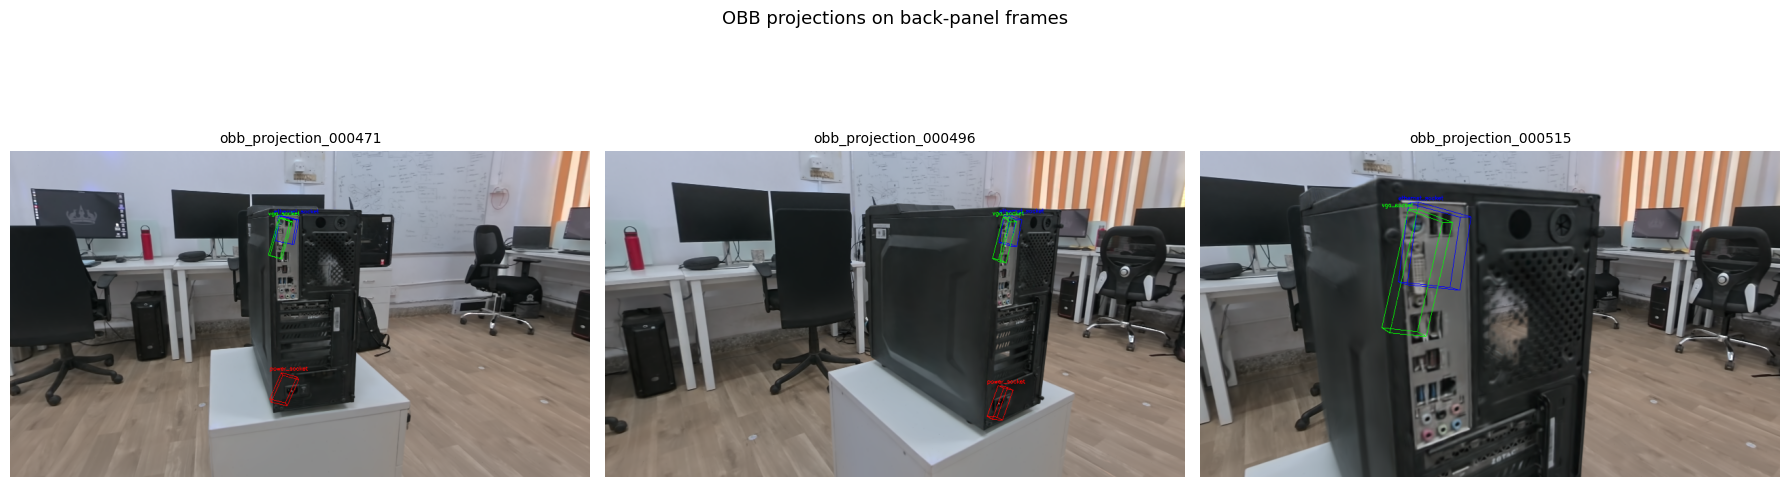


── answers.json ──
[
  {
    "entity": "power_socket",
    "obb": {
      "center": [
        0.2708955588204567,
        0.20727058934281192,
        0.5402578749033937
      ],
      "extent": [
        0.029682441599668482,
        0.018031076027311452,
        0.006
      ],
      "rotation": [
        [
          0.4142204206242773,
          0.9000349157117599,
          -0.13549388781628563
        ],
        [
          0.029719786818597417,
          0.13541137480578777,
          0.9903436241238006
        ],
        [
          0.9096912538788097,
          -0.4142474020027365,
          0.029341310804726416
        ]
      ]
    }
  },
  {
    "entity": "ethernet_socket",
    "obb": {
      "center": [
        0.28196334499701864,
        0.2246744750301212,
        0.849515487267156
      ],
      "extent": [
        0.022527307002642962,
        0.017686075307721913,
        0.006
      ],
      "rotation": [
        [
          0.2078100380505025,
          0.9689848272

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [10]:
# ── Cell 6: Show OBB projections inline + download answers.json ───────────────
import cv2, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
import src.config as cfg
from google.colab import files

proj_dir = Path(cfg.OUTPUT_DIR) / "detections"
proj_imgs = sorted(proj_dir.glob("obb_projection_*.png"))
if proj_imgs:
    fig, axes = plt.subplots(1, len(proj_imgs), figsize=(18, 6))
    if len(proj_imgs) == 1:
        axes = [axes]
    for ax, p in zip(axes, proj_imgs):
        img = cv2.cvtColor(cv2.imread(str(p)), cv2.COLOR_BGR2RGB)
        # Downscale for display
        h, w = img.shape[:2]
        img  = cv2.resize(img, (w//3, h//3))
        ax.imshow(img)
        ax.set_title(p.stem, fontsize=10)
        ax.axis("off")
    plt.suptitle("OBB projections on back-panel frames", fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("[INFO] No OBB projection images found — run Cell 5 first")

# Print final answers
import json
answers_path = Path(cfg.OUTPUT_DIR) / "answers.json"
if answers_path.exists():
    print("\n── answers.json ──")
    print(json.dumps(json.loads(answers_path.read_text()), indent=2))
    print("\n📥 Downloading answers.json...")
    files.download(str(answers_path))
else:
    print("[ERROR] answers.json not found — run Cell 5 first")

In [11]:
# ── Cell 7 (Optional): Add bonus entity on exam day ──────────────────────────
# On exam day, look at the frame images and find the pixel bbox for the bonus
# entity. Add it to BONUS_ANNOTATIONS below, then run this cell.

import sys, json, numpy as np
sys.path.insert(0, "/content/project")

from src.semantic       import ENTITY_ANNOTATIONS
from src.pose_estimation import triangulate_roi_multiview, fit_obb_with_depth
from src.data_loader    import load_dataset
from src.utils          import save_answers_json
import src.config as cfg
from pathlib import Path

# ── FILL IN ON EXAM DAY ───────────────────────────────────────────────────────
BONUS_ENTITY = "usb_port"   # ← change to actual bonus entity
BONUS_ANNOTATIONS = {
    # Example — replace with actual pixel coords
    471: [1200, 500, 1320, 570],
    496: [1760, 500, 1880, 570],
}
# ─────────────────────────────────────────────────────────────────────────────

images, poses, K = load_dataset()

all_ann = {BONUS_ENTITY: BONUS_ANNOTATIONS}
pts = triangulate_roi_multiview(BONUS_ENTITY, all_ann, K, poses, 400)

if len(pts) >= 3:
    obb = fit_obb_with_depth(pts, BONUS_ENTITY, all_ann, K, poses)
    if obb:
        print(f"✅ {BONUS_ENTITY}")
        print(f"   Center: {np.round(obb['center'], 4).tolist()}")
        print(f"   Extent: {np.round(obb['extent'], 4).tolist()}")

        # Append to existing results and re-export
        answers_path = Path(cfg.OUTPUT_DIR) / "answers.json"
        existing = json.loads(answers_path.read_text()) if answers_path.exists() else []
        existing = [r for r in existing if r["entity"] != BONUS_ENTITY]
        existing.append({"entity": BONUS_ENTITY, "obb": obb})
        save_answers_json(existing, str(answers_path))

        from google.colab import files
        files.download(str(answers_path))
else:
    print("❌ Not enough 3D points — check bbox coordinates")

[1/3] Loading intrinsics...
[2/3] Loading poses...
[3/3] Loading images...
  Loaded 16 images, 16 poses
  usb_port: triangulated 400 3D points
✅ usb_port
   Center: [0.2968, 0.2154, 0.778]
   Extent: [0.0236, 0.013, 0.006]
  Saved answers to /content/project/output/answers.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
# ── Cell 8 (Optional): transforms.json for 3DGS ──────────────────────────────
import json, sys
sys.path.insert(0, "/content/project")

from src.data_loader import load_dataset
import src.config as cfg
from pathlib import Path

images, poses, K = load_dataset()
frame_ids = sorted(poses.keys())

frames_list = [
    {
        "file_path": str(Path(cfg.DATA_DIR) / f"frame_{fid:06d}.png"),
        "transform_matrix": poses[fid].tolist()
    }
    for fid in frame_ids
]

transforms = {
    "fl_x": float(K[0,0]), "fl_y": float(K[1,1]),
    "cx":   float(K[0,2]), "cy":   float(K[1,2]),
    "w": cfg.IMAGE_WIDTH,  "h": cfg.IMAGE_HEIGHT,
    "frames": frames_list,
}

out = Path(cfg.OUTPUT_DIR) / "transforms.json"
out.write_text(json.dumps(transforms, indent=2))
print(f"✅ transforms.json written ({len(frames_list)} frames)")

from google.colab import files
files.download(str(out))

# Uncomment to train 3DGS with nerfstudio (requires separate install):
# !ns-train gaussian-splatting --data /content/project/output --output-dir /content/project/output/gs --max-num-iterations 30000

[1/3] Loading intrinsics...
[2/3] Loading poses...
[3/3] Loading images...
  Loaded 16 images, 16 poses
✅ transforms.json written (16 frames)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>